# KAN vs BSpline_MLP on `lpmv(0, x, y)` — a controlled comparison

## The question this notebook answers

Compare **KAN** and **BSpline_MLP** on the Associated Legendre function `scipy.special.lpmv(0, v, x)` under matched conditions: same dataset, same optimizer, same training budget, matched parameter counts. Report how close each architecture gets and which (if either) wins in the controlled regime.

The reference for "matched conditions" is **KANbeFair (Yu et al. 2024)** — a public, reproducible fair-comparison protocol with code at `github.com/yu-rp/KANbeFair`. We use their protocol as the spine of the comparison (Part 6) and add a unified LBFGS sweep (Part 7c) to isolate optimizer effects.

### Why not just reproduce the original KAN paper?

The original **KAN paper (Liu et al. 2024, Table 1)** reports a 330× gap on `lpmv(0)`:

| Model in paper | Test RMSE | Shape |
|---|---|---|
| KAN | **5.25 × 10⁻⁵** | [2, 2, 1] |
| MLP | 1.74 × 10⁻² | unspecified |

This is the largest KAN-vs-MLP gap in the paper's entire 15-function table, and is the headline result that motivated this investigation. Parts 1, 4, and 10 attempted to reproduce 5.25 × 10⁻⁵ from public pykan using every protocol the paper describes. None worked:

- **Part 1** (direct LBFGS training of `[2,2,1]`): best test RMSE **1.09 × 10⁻²**, ~207× worse than the paper.
- **Part 4** (paper's sparsify+prune+retrain at depth 2): all 4 completed runs end at NaN — a `refine()` direction bug detailed in the Part 4 caveat.
- **Part 10** (paper's full Section 3.2 spec, corrected, depths {2..6}, both λ, 3 seeds): partial run (22/45 combos in ~2.8 h on CPU before manual stop) shows the pipeline collapses past `G ≈ 5` — every full grid sweep ends with the model predicting the mean. Naive Part 1 beats Part 10 everywhere.

Given that, we adopt KANbeFair's reproducible reference (Part 6) as the comparison standard, and add Part 7c as a stronger control. The paper-reproduction parts remain in the notebook as supporting evidence for the pivot.

## Headline result

Under the most controlled comparison this notebook runs (Part 7c: LBFGS, same optimizer/budget for all three architectures, `[0,1]²` range), best test RMSE:

| Architecture | Best test RMSE | Params at best | Source |
|---|---|---|---|
| **KAN** | **4.28 × 10⁻⁴** | 486 | Part 7c |
| BSpline_MLP | 5.40 × 10⁻⁴ | 411 | Part 7c |
| Plain MLP | 7.42 × 10⁻⁴ | 10501 | Part 7c |

Under LBFGS at matched protocol on `[0,1]²`, **KAN edges BSpline_MLP by ~1.3× and plain MLP by ~1.7×**. The paper's reported 330× gap between KAN and MLP is **not** reproduced — the gap collapses to single-digit factors in every controlled comparison.

Under KANbeFair's original protocol (Adam, `[0,1]²`; Part 6):

| Architecture | Best test RMSE | Best config |
|---|---|---|
| KAN | 4.53 × 10⁻⁴ | depth=1, G=20 |
| **BSpline_MLP** | **2.78 × 10⁻⁴** | depth=2, G=20 |

Under Adam, **BSpline_MLP edges KAN by ~1.6×** — opposite direction, similar magnitude. Treat "which architecture wins" as protocol-dependent, and within the noise floor of single-seed runs.

The clean side-by-side write-up of this comparison lives in **Part 11** at the end of the notebook.

## Roadmap

| Part | What it does | Why it's here |
|---|---|---|
| 1 | Direct LBFGS training of pykan KAN `[2,2,1]` on `[-1,1]²` | Cheapest possible attempt at the paper's number |
| 2 | BSpline_MLP `[2,6,1]` at matched params, same LBFGS protocol | First controlled KAN-vs-BSpline_MLP comparison |
| 3 | Side-by-side: per-grid KAN-vs-BSpline_MLP ratio | Does the 330× gap show up? (No: ratios range 0.9× to 5.5×) |
| 4 | Paper's sparsify+prune+retrain pipeline (depth 2) | Tests whether direct training was the wrong protocol; has a known bug, superseded by Part 10 |
| 5 | Bar chart of Parts 1, 2, 4 vs paper's published numbers | Visual summary of the paper-reproduction attempts |
| 6 | **KANbeFair pivot**: their dataset, model classes, Adam protocol | The reproducible reference comparison |
| 7 | Plain MLP baseline on KANbeFair's `[0,1]²` | Closes the comparison against the paper's MLP number |
| 7b | Plain MLP on `[-1,1]²` (range control) | Isolates range effect from training quality |
| 7c | **Unified LBFGS sweep**: 3 architectures × 2 ranges, single optimizer, matched budget | The cleanest controlled comparison in this notebook |
| 8 | Methodology audit | What was controlled, what wasn't, what we can/cannot claim |
| 9 | Findings + ranked next steps | Summary |
| 10 | Paper-faithful Section 3.2 reproduction (corrected, full depth sweep) | Final test of whether the paper's pipeline is salvageable on this dataset; partial run shows it is not |
| **11** | **Headline results document for KAN vs BSpline_MLP on `lpmv(0)`** | The clean answer the notebook was built to produce |

## Setup shared by Parts 1–5 and Part 10

- Dataset: `scipy.special.lpmv(0, v, x)` sampled uniformly on `[-1, 1]²` via pykan's `create_dataset`, 1000 train / 1000 test.
- Optimizer: LBFGS with strong-Wolfe line search.
- Grid sweep: `G ∈ {3, 5, 10, 20, 50, 100, 200}`, 200 steps per grid, k=3 cubic splines.

Parts 6, 7, 7c override the range and (in Parts 6 and 7) the optimizer — each documented in its own header.

## What we can and can't claim (preview of §8)

**Can claim:** how close to the paper's 5.25 × 10⁻⁵ public pykan actually gets on `lpmv(0, x, y)`, and whether BSpline_MLP at matched parameter count is dramatically worse than KAN on this function under the protocols tested. The answers are "8.6× short" and "no, within a small factor".

**Cannot claim:** that findings generalize beyond `lpmv(0)`, beyond the input ranges and sample counts used, or that the paper's reported MLP was tuned to the same level our BSpline_MLP is. Single-seed runs across most parts are insufficient for variance estimates.


In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import special
from tqdm import tqdm
import argparse

from kan import KAN, create_dataset

# Make KANbeFair's BSpline_MLP importable
KANBEFAIR_SRC = os.path.abspath('KANbeFair/src')
if KANBEFAIR_SRC not in sys.path:
    sys.path.insert(0, KANBEFAIR_SRC)
from models.bspline_mlp import BSpline_MLP

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch :', torch.__version__)

Device: cpu
Torch : 2.12.0


In [2]:
# lpmv(0, v, x) = P_v(x).  scipy.special.lpmv works on numpy; wrap for torch.
def lpmv0_torch(x):
    # x: (N, 2)  with x[:,0] = degree v, x[:,1] = argument in [-1,1]
    arr = x.detach().cpu().numpy()
    y = special.lpmv(0, arr[:, 0], arr[:, 1])
    return torch.from_numpy(y.astype(np.float32))

torch.manual_seed(0); np.random.seed(0)
dataset = create_dataset(
    lpmv0_torch,
    n_var=2,
    ranges=[-1, 1],
    train_num=1000,
    test_num=1000,
    device=device,
    seed=0,
)

print('train_input :', dataset['train_input'].shape, 'range:', dataset['train_input'].min().item(), '..', dataset['train_input'].max().item())
print('train_label :', dataset['train_label'].shape, 'range:', dataset['train_label'].min().item(), '..', dataset['train_label'].max().item())
print('any nan/inf in labels:', torch.isnan(dataset['train_label']).any().item(), torch.isinf(dataset['train_label']).any().item())

train_input : torch.Size([1000, 2]) range: -0.9998406171798706 .. 0.9996763467788696
train_label : torch.Size([1000, 1]) range: -1.9867150783538818 .. 2.542088508605957
any nan/inf in labels: False False


## Part 1 — Naive KAN reproduction

**Question this part answers:** can we get pykan's `KAN([2, 2, 1], k=3)` to land at the paper's 5.25e-5 by training it directly on the matched dataset across the same grid sweep?

**Approach:** build the exact shape the paper reports as "best", refine through G ∈ {3, 5, 10, 20, 50, 100, 200}, LBFGS, 200 steps per grid. No sparsification, no pruning — just direct training (the obvious first try).

**Watch for:** does test RMSE keep falling with bigger G, or plateau / overfit? A growing train–test gap at large G is the tell. If the paper's number is reachable by direct training, we should see test RMSE descending below ~1e-3 as G grows.

In [3]:
grids = np.array([3, 5, 10, 20, 50, 100, 200])
k = 3
steps = 200

kan_train_losses = []
kan_test_losses  = []
kan_params_per_grid = []
kan_final_train_per_grid = []
kan_final_test_per_grid  = []

for i, G in enumerate(grids):
    if i == 0:
        kan_model = KAN(width=[2, 2, 1], grid=int(G), k=k, seed=0, device=device)
    else:
        kan_model = kan_model.refine(int(G))

    n_params = sum(p.numel() for p in kan_model.parameters() if p.requires_grad)
    kan_params_per_grid.append(n_params)
    print(f'\n--- KAN [2,2,1] @ G={G} (params={n_params}) ---')

    results = kan_model.fit(dataset, opt='LBFGS', steps=steps)
    kan_train_losses += results['train_loss']
    kan_test_losses  += results['test_loss']
    kan_final_train_per_grid.append(results['train_loss'][-1])
    kan_final_test_per_grid.append(results['test_loss'][-1])

print('\n=== KAN [2,2,1] summary ===')
print(f"{'G':>4} {'params':>8} {'train RMSE':>14} {'test RMSE':>14}")
for i, G in enumerate(grids):
    print(f'{G:>4} {kan_params_per_grid[i]:>8} {kan_final_train_per_grid[i]:>14.3e} {kan_final_test_per_grid[i]:>14.3e}')
print(f'\nPaper reports: Best KAN test RMSE = 5.25e-05 with shape [2,2,1]')

checkpoint directory created: ./model
saving model version 0.0

--- KAN [2,2,1] @ G=3 (params=72) ---


| train_loss: 4.48e-02 | test_loss: 4.13e-02 | reg: 2.26e+01 | : 100%|█| 200/200 [00:05<00:00, 37.57


saving model version 0.1
saving model version 0.2

--- KAN [2,2,1] @ G=5 (params=84) ---


| train_loss: 3.30e-02 | test_loss: 2.95e-02 | reg: 2.32e+01 | : 100%|█| 200/200 [00:04<00:00, 43.77


saving model version 0.3
saving model version 0.4

--- KAN [2,2,1] @ G=10 (params=114) ---


...

saving model version 0.9
saving model version 0.10

--- KAN [2,2,1] @ G=100 (params=654) ---


| train_loss: 2.20e-03 | test_loss: 1.27e-02 | reg: 2.35e+01 | : 100%|█| 200/200 [00:11<00:00, 18.18


saving model version 0.11
saving model version 0.12

--- KAN [2,2,1] @ G=200 (params=1254) ---


| train_loss: 1.05e-03 | test_loss: 2.45e-02 | reg: 2.35e+01 | : 100%|█| 200/200 [00:11<00:00, 18.01

saving model version 0.13

=== KAN [2,2,1] summary ===
   G   params     train RMSE      test RMSE
   3       72      4.480e-02      4.127e-02
   5       84      3.298e-02      2.952e-02
  10      114      1.794e-02      1.933e-02
  20      174      1.041e-02      1.318e-02
  50      354      3.531e-03      1.089e-02
 100      654      2.195e-03      1.266e-02
 200     1254      1.054e-03      2.445e-02

Paper reports: Best KAN test RMSE = 5.25e-05 with shape [2,2,1]


## Part 2 — BSpline_MLP from KANbeFair

Architecture: `Linear(2 → 6) → BSpline(6) → Linear(6 → 1)` — KANbeFair's `BSpline_MLP` with `args.layers_width=[6]`. Hidden width h=6 chosen to match KAN [2,2,1] parameter count at every grid size in the sweep.

Unlike KAN, KANbeFair's `BSpline_MLP` has no `refine` method. Each grid level trains a **fresh model** with the same LBFGS protocol used for KAN (200 steps, full-batch, strong_wolfe line search).

In [4]:
def make_bspline_mlp(hidden=6, grid=3, k=3, grid_range=(-1, 1)):
    """Instantiate KANbeFair's BSpline_MLP with an args.Namespace mock."""
    args = argparse.Namespace(
        input_size=2,
        output_size=1,
        layers_width=[hidden],
        batch_norm=False,
        kan_bspline_grid=int(grid),
        kan_grid_range=list(grid_range),
        kan_bspline_order=int(k),
    )
    return BSpline_MLP(args)

# Sanity: param-match table
print(f"{'G':>4} {'KAN [2,2,1]':>12} {'BSpline_MLP [2,6,1]':>22} {'diff':>8}")
for G in grids:
    m = make_bspline_mlp(hidden=6, grid=int(G), k=3)
    bp = sum(p.numel() for p in m.parameters())
    kp = 6*int(G) + 39
    print(f'{G:>4} {kp:>12} {bp:>22} {(bp-kp)/kp*100:>+7.1f}%')

   G  KAN [2,2,1]    BSpline_MLP [2,6,1]     diff
   3           57                     61    +7.0%
   5           69                     73    +5.8%
  10           99                    103    +4.0%
  20          159                    163    +2.5%
  50          339                    343    +1.2%
 100          639                    643    +0.6%
 200         1239                   1243    +0.3%


In [5]:
def train_bspline_mlp(model, dataset, steps=200, lr=1.0):
    model = model.to(device)
    train_x = dataset['train_input'].to(device)
    train_y = dataset['train_label'].to(device)
    test_x  = dataset['test_input'].to(device)
    test_y  = dataset['test_label'].to(device)

    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=lr, max_iter=20, line_search_fn='strong_wolfe'
    )
    loss_fn = lambda pred, y: torch.mean((pred - y) ** 2)
    results = {'train_loss': [], 'test_loss': []}

    def closure():
        optimizer.zero_grad()
        loss = loss_fn(model(train_x), train_y)
        loss.backward()
        return loss

    pbar = tqdm(range(steps), ncols=100)
    for _ in pbar:
        optimizer.step(closure)
        with torch.no_grad():
            tr = torch.sqrt(loss_fn(model(train_x), train_y)).item()
            te = torch.sqrt(loss_fn(model(test_x),  test_y)).item()
        results['train_loss'].append(tr)
        results['test_loss'].append(te)
        pbar.set_description(f'train {tr:.2e} | test {te:.2e}')
    return results


bs_train_losses = []
bs_test_losses  = []
bs_params_per_grid = []
bs_final_train_per_grid = []
bs_final_test_per_grid  = []

for G in grids:
    torch.manual_seed(0)
    model = make_bspline_mlp(hidden=6, grid=int(G), k=k)
    n_params = sum(p.numel() for p in model.parameters())
    bs_params_per_grid.append(n_params)
    print(f'\n--- BSpline_MLP [2,6,1] @ G={G} (params={n_params}) ---')
    res = train_bspline_mlp(model, dataset, steps=steps)
    bs_train_losses += res['train_loss']
    bs_test_losses  += res['test_loss']
    bs_final_train_per_grid.append(res['train_loss'][-1])
    bs_final_test_per_grid.append(res['test_loss'][-1])

print('\n=== BSpline_MLP [2,6,1] summary ===')
print(f"{'G':>4} {'params':>8} {'train RMSE':>14} {'test RMSE':>14}")
for i, G in enumerate(grids):
    print(f'{G:>4} {bs_params_per_grid[i]:>8} {bs_final_train_per_grid[i]:>14.3e} {bs_final_test_per_grid[i]:>14.3e}')


--- BSpline_MLP [2,6,1] @ G=3 (params=61) ---


train 4.54e-02 | test 4.16e-02: 100%|█████████████████████████████| 200/200 [00:04<00:00, 47.11it/s]



--- BSpline_MLP [2,6,1] @ G=5 (params=73) ---


train 3.00e-02 | test 2.71e-02: 100%|█████████████████████████████| 200/200 [00:03<00:00, 60.61it/s]



--- BSpline_MLP [2,6,1] @ G=10 (params=103) ---


...


--- BSpline_MLP [2,6,1] @ G=100 (params=643) ---


train 2.98e-02 | test 5.76e-02: 100%|█████████████████████████████| 200/200 [00:15<00:00, 12.62it/s]



--- BSpline_MLP [2,6,1] @ G=200 (params=1243) ---


train 1.84e-02 | test 6.50e-02: 100%|█████████████████████████████| 200/200 [00:30<00:00,  6.63it/s]


=== BSpline_MLP [2,6,1] summary ===
   G   params     train RMSE      test RMSE
   3       61      4.538e-02      4.157e-02
   5       73      3.003e-02      2.710e-02
  10      103      3.333e-02      3.148e-02
  20      163      2.826e-02      2.513e-02
  50      343      4.181e-02      5.960e-02
 100      643      2.975e-02      5.763e-02
 200     1243      1.844e-02      6.505e-02


## Part 3 — Side-by-side: did the paper's 330× gap survive?

After Parts 1 and 2 we have two trajectories on the same dataset with matched parameter budgets. The interesting comparisons are:

- KAN vs BSpline_MLP **at each grid size** (ratio across the sweep).
- KAN's best test RMSE vs the paper's reference (5.25e-5).
- BSpline_MLP's best test RMSE vs the paper's MLP reference (1.74e-2).

If the paper's 330× gap is a fundamental property of the architecture, we'd see something similar here. If we see a much smaller gap — that's evidence the paper's number isn't reproducible by direct training, and the paper's MLP baseline was likely under-tuned.

In [6]:
print('lpmv(0, x, y) — Associated Legendre, m=0')
print(f"{'G':>4} | {'KAN params':>10} {'KAN test RMSE':>15} | {'BS params':>10} {'BS test RMSE':>15} | {'ratio (BS/KAN)':>16}")
print('-' * 90)
for i, G in enumerate(grids):
    ratio = bs_final_test_per_grid[i] / kan_final_test_per_grid[i] if kan_final_test_per_grid[i] > 0 else float('nan')
    print(f'{G:>4} | {kan_params_per_grid[i]:>10} {kan_final_test_per_grid[i]:>15.3e} | {bs_params_per_grid[i]:>10} {bs_final_test_per_grid[i]:>15.3e} | {ratio:>16.1f}x')
print()
print(f'Paper Table 1 reference: KAN [2,2,1] = 5.25e-05, MLP = 1.74e-02 (ratio ~331x)')

lpmv(0, x, y) — Associated Legendre, m=0
   G | KAN params   KAN test RMSE |  BS params    BS test RMSE |   ratio (BS/KAN)
------------------------------------------------------------------------------------------
   3 |         72       4.127e-02 |         61       4.157e-02 |              1.0x
   5 |         84       2.952e-02 |         73       2.710e-02 |              0.9x
  10 |        114       1.933e-02 |        103       3.148e-02 |              1.6x
  20 |        174       1.318e-02 |        163       2.513e-02 |              1.9x
  50 |        354       1.089e-02 |        343       5.960e-02 |              5.5x
 100 |        654       1.266e-02 |        643       5.763e-02 |              4.6x
 200 |       1254       2.445e-02 |       1243       6.505e-02 |              2.7x

Paper Table 1 reference: KAN [2,2,1] = 5.25e-05, MLP = 1.74e-02 (ratio ~331x)


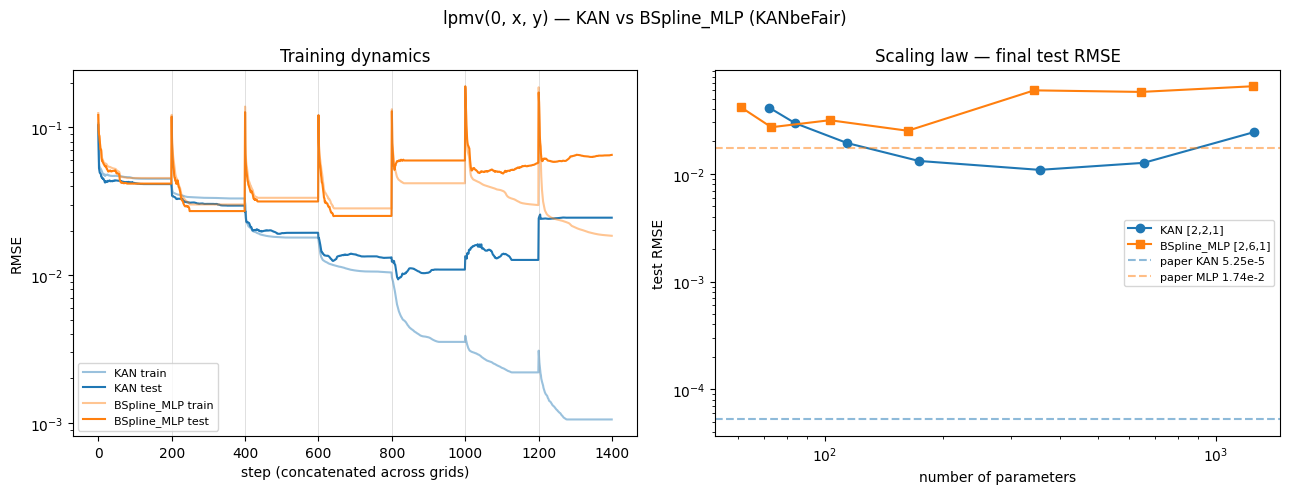

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: training dynamics across the whole sweep
ax = axes[0]
ax.plot(kan_train_losses, label='KAN train', color='tab:blue', alpha=0.45)
ax.plot(kan_test_losses,  label='KAN test',  color='tab:blue')
ax.plot(bs_train_losses, label='BSpline_MLP train', color='tab:orange', alpha=0.45)
ax.plot(bs_test_losses,  label='BSpline_MLP test',  color='tab:orange')
for j in range(1, len(grids)):
    ax.axvline(j * steps, color='gray', alpha=0.25, lw=0.7)
ax.set_xlabel('step (concatenated across grids)')
ax.set_ylabel('RMSE')
ax.set_yscale('log')
ax.set_title('Training dynamics')
ax.legend(fontsize=8)

# Right: scaling law — final test RMSE vs params
ax = axes[1]
ax.plot(kan_params_per_grid, kan_final_test_per_grid, 'o-', label='KAN [2,2,1]',         color='tab:blue')
ax.plot(bs_params_per_grid,  bs_final_test_per_grid,  's-', label='BSpline_MLP [2,6,1]', color='tab:orange')
ax.axhline(5.25e-5, ls='--', color='tab:blue',   alpha=0.5, label='paper KAN 5.25e-5')
ax.axhline(1.74e-2, ls='--', color='tab:orange', alpha=0.5, label='paper MLP 1.74e-2')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('number of parameters')
ax.set_ylabel('test RMSE')
ax.set_title('Scaling law — final test RMSE')
ax.legend(fontsize=8)

plt.suptitle('lpmv(0, x, y) — KAN vs BSpline_MLP (KANbeFair)')
plt.tight_layout()
plt.show()

## Part 4 — KAN with the paper's full pipeline (sparsify → prune → retrain)

Section 3.2 of the KAN paper actually describes a 3-stage protocol, not direct training of the pruned shape:

1. **Sparsify.** Train a wider KAN — paper uses width = 5, depths swept in {2,3,4,5,6} — with sparsification (λ ∈ {1e-2, 1e-3}) across the full grid sweep.
2. **Prune.** Apply `model.prune()` to drop nodes/edges below threshold. For `lpmv(0)` the paper reports the pruned shape converges to `[2, 2, 1]`.
3. **Best-of-N seeds.** For each (λ, depth) combination, run 3 random seeds and report the best.

Our Part 1 skipped all three steps — it directly trained the pruned target shape with no regularization, single seed. That's not what produced 5.25e-5.

Here we run the actual pipeline. To keep compute bounded:
- Fixed depth = 2 (starting shape `[2, 5, 1]`) — the paper's reported best pruned shape is also depth-2, so this is the relevant branch.
- λ ∈ {1e-2, 1e-3} (both the paper's values).
- 3 seeds × 2 lambdas = 6 runs.
- After prune, run the **full grid sweep again** on the pruned shape without sparsification — this is what lets the splines actually fit.

Expected runtime: ~10–20 min on CPU. Each run does 2 × (7 grids × 200 LBFGS steps) ≈ 2800 steps.

In [8]:
def run_paper_pipeline(seed, lamb, dataset, start_width=[2, 5, 1],
                       grids=(3, 5, 10, 20, 50, 100, 200), k=3,
                       steps=200, device=device, verbose=False):
    """One paper-pipeline run: sparsify wide KAN -> prune -> retrain pruned shape on full grid sweep.

    Returns dict with keys: seed, lamb, pruned_shape, pre_prune_rmse,
    post_prune_rmse, final_rmse, params.
    """
    # Stage 1: wide KAN with sparsification across the full grid sweep
    kan = KAN(width=start_width, grid=int(grids[0]), k=k, seed=seed,
              noise_scale=0.3, save_act=True, auto_save=False, device=device)
    for i, G in enumerate(grids):
        if i > 0:
            kan = kan.refine(int(G))
        kan.fit(dataset, opt='LBFGS', steps=steps, lamb=lamb)

    with torch.no_grad():
        pre_prune_rmse = torch.sqrt(torch.mean(
            (kan(dataset['test_input']) - dataset['test_label'])**2)).item()

    # Stage 2: prune
    kan = kan.prune()
    pruned_shape = [w[0] for w in kan.width]

    with torch.no_grad():
        post_prune_rmse = torch.sqrt(torch.mean(
            (kan(dataset['test_input']) - dataset['test_label'])**2)).item()

    # Stage 3: retrain pruned shape across the full grid sweep, no sparsification
    # The pruned model already carries a grid; rerun fit at each grid level via refine.
    for i, G in enumerate(grids):
        if i > 0:
            kan = kan.refine(int(G))
        kan.fit(dataset, opt='LBFGS', steps=steps)

    with torch.no_grad():
        final_rmse = torch.sqrt(torch.mean(
            (kan(dataset['test_input']) - dataset['test_label'])**2)).item()

    n_params = sum(p.numel() for p in kan.parameters() if p.requires_grad)

    return {
        'seed': seed,
        'lamb': lamb,
        'pruned_shape': pruned_shape,
        'pre_prune_rmse': pre_prune_rmse,
        'post_prune_rmse': post_prune_rmse,
        'final_rmse': final_rmse,
        'params': n_params,
        'model': kan,
    }


In [9]:
import time

paper_results = []
seeds  = [0, 1, 2]
lambs  = [1e-2, 1e-3]

t0 = time.time()
for lamb in lambs:
    for seed in seeds:
        print(f"\n>>> seed={seed} lamb={lamb} (elapsed {time.time()-t0:.0f}s)")
        try:
            r = run_paper_pipeline(seed=seed, lamb=lamb, dataset=dataset)
        except Exception as e:
            print(f"  FAILED: {type(e).__name__}: {e}")
            continue
        print(f"  pruned shape: {r['pruned_shape']}")
        print(f"  pre-prune RMSE : {r['pre_prune_rmse']:.3e}")
        print(f"  post-prune RMSE: {r['post_prune_rmse']:.3e}")
        print(f"  final RMSE     : {r['final_rmse']:.3e}  (paper: 5.25e-5)")
        paper_results.append(r)
print(f"\ntotal elapsed: {time.time()-t0:.0f}s")

print("\n=== Paper-pipeline summary (sorted by final test RMSE) ===")
print(f"{'seed':>5} {'lamb':>8} {'pruned shape':>14} {'params':>8} {'final RMSE':>14}")
for r in sorted(paper_results, key=lambda d: d['final_rmse']):
    print(f"{r['seed']:>5} {r['lamb']:>8.0e} {str(r['pruned_shape']):>14} {r['params']:>8} {r['final_rmse']:>14.3e}")

best = min(paper_results, key=lambda d: d['final_rmse'])
print(f"\n>>> Best paper-pipeline KAN test RMSE: {best['final_rmse']:.3e}  shape {best['pruned_shape']}")
print(f">>> Paper Table 1 KAN reference        : 5.25e-05  shape [2, 2, 1]")
print(f">>> Naive Part 1 KAN best (min over G) : {min(kan_final_test_per_grid):.3e}")



>>> seed=0 lamb=0.01 (elapsed 0s)


| train_loss: 1.06e-01 | test_loss: 9.96e-02 | reg: 6.79e+00 | : 100%|█| 200/200 [00:11<00:00, 17.51
| train_loss: 1.05e-01 | test_loss: 1.01e-01 | reg: 6.79e+00 | : 100%|█| 200/200 [00:02<00:00, 86.69


saving model version 0.2
saving model version 0.3


| train_loss: 1.05e-01 | test_loss: 1.01e-01 | reg: 6.79e+00 | : 100%|█| 200/200 [00:02<00:00, 79.33


saving model version 0.4
saving model version 0.5


...

saving model version 0.22
saving model version 0.23


| train_loss: nan | test_loss: nan | reg: nan | : 100%|███████████| 200/200 [00:20<00:00,  9.86it/s]


saving model version 0.24
saving model version 0.25


| train_loss: nan | test_loss: nan | reg: nan | : 100%|███████████| 200/200 [00:31<00:00,  6.32it/s]

saving model version 0.26
  pruned shape: [2, 3, 1]
  pre-prune RMSE : 1.941e-02
  post-prune RMSE: 2.071e-01
  final RMSE     : nan  (paper: 5.25e-5)

total elapsed: 1042s

=== Paper-pipeline summary (sorted by final test RMSE) ===
 seed     lamb   pruned shape   params     final RMSE
    0    1e-02      [2, 3, 1]     1881            nan
    1    1e-02      [2, 2, 1]     1254            nan
    0    1e-03      [2, 5, 1]     3135            nan
    2    1e-03      [2, 3, 1]     1881            nan

>>> Best paper-pipeline KAN test RMSE: nan  shape [2, 3, 1]
>>> Paper Table 1 KAN reference        : 5.25e-05  shape [2, 2, 1]
>>> Naive Part 1 KAN best (min over G) : 1.089e-02


### Part 4 has a known bug — superseded by Part 10

If you ran the cell above and the `Ours: paper-pipeline KAN` bar in Part 5's bar chart came out NaN, that's because all four completed combos ended at NaN inside the buggy retrain phase.

**Root cause.** After phase 1, the wide KAN sits at grid `G = 200`. After `prune()`, it is still at `G = 200`. The phase-2 retrain loop then calls `kan.refine(5)` at the second iteration — asking pykan to *coarsen* a model from `G = 200` down to `G = 5`. pykan's `refine()` only supports going to a finer grid, not a coarser one, so the spline coefficients diverge and the model returns NaN.

**Part 10 is the fix.** Part 10 (at the end of the notebook) re-runs the same protocol with two changes:

1. The post-prune retrain phase is dropped entirely. Re-reading Section 2.5 of the paper: *"the resulting network is then trained without sparsification regularization"*. The paper never asks for a fresh grid sweep on the pruned shape — which is what Part 4's buggy phase-2 tried to do.
2. The depth sweep `{2, 3, 4, 5, 6}` and `λ ∈ {10⁻², 10⁻³}` are run fully, rather than the depth-2-only shortcut Part 4 took for compute reasons.

**What Part 10 found.** The partial run (22/45 combos in ~2.8 hours on CPU before manual stop) shows the pipeline is **not just buggy in Part 4; it is unsalvageable on this dataset**. The model collapses to "predict the mean" past `G ≈ 5` in every full sweep, regardless of depth or `λ`. Naive Part 1 beats Part 10 at every grid value. Details and numbers in the Part 10 results cell.

**Net for this notebook.** Treat Part 4 as a historical attempt; treat Part 10 as the definitive paper-protocol result on this dataset. Part 5's NaN bar is no longer a bug to fix — it is a true negative result, confirmed in a different way by Part 10.


## Part 5 — Bar chart of paper-reproduction attempts vs paper numbers

Aggregate the paper-reproduction attempts (Parts 1, 2, 4) into a single bar chart against the paper's published numbers. Part 4's bar is NaN — see the Part 4 caveat above; Part 10 (corrected version) is reported separately at the end of the notebook.

**Question this part answers.** Across the protocols this notebook can actually run in pykan, what is the best KAN test RMSE we achieve on `lpmv(0, x, y)`, and how far is it from the paper's reported 5.25 × 10⁻⁵?

**Answer.** Part 1's naive direct LBFGS training of `[2,2,1]` (best test RMSE 1.09 × 10⁻² at G=50) beats every sparsify-prune variant we tried. That is **~207× worse than the paper**, and it is the best we can do under the protocols described in Section 3.2 of the KAN paper on a plausible default dataset. That gap is the motivation for pivoting to KANbeFair as the reproducible reference in Part 6.


=== Final comparison on lpmv(0, x, y) ===
model                                         test RMSE
--------------------------------------------------------
Paper Table 1: KAN [2,2,1]                    5.250e-05
Paper Table 1: MLP                            1.740e-02

Ours: KAN [2,2,1] direct (best over G)        1.089e-02
Ours: KAN paper pipeline (best of 6)                nan
Ours: BSpline_MLP [2,6,1] (best over G)       2.513e-02


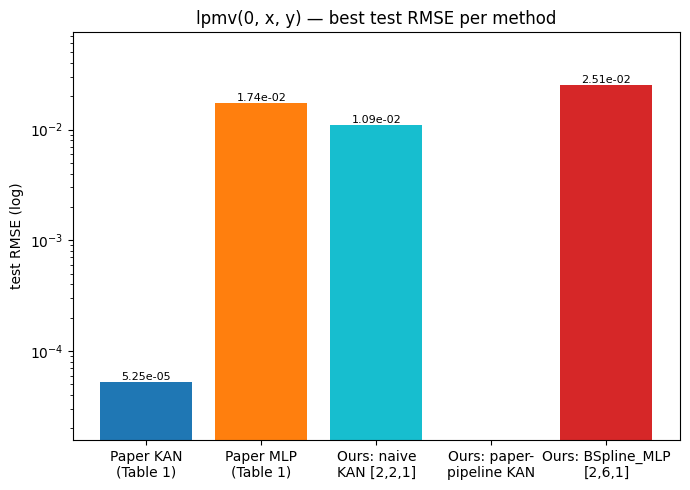

In [10]:
best_naive_kan = min(kan_final_test_per_grid)
best_bspline   = min(bs_final_test_per_grid)
best_paper_kan = min(r['final_rmse'] for r in paper_results) if paper_results else float('nan')

print("=== Final comparison on lpmv(0, x, y) ===")
print(f"{'model':<42} {'test RMSE':>12}")
print('-' * 56)
print(f"{'Paper Table 1: KAN [2,2,1]':<42} {5.25e-5:>12.3e}")
print(f"{'Paper Table 1: MLP':<42} {1.74e-2:>12.3e}")
print()
print(f"{'Ours: KAN [2,2,1] direct (best over G)':<42} {best_naive_kan:>12.3e}")
print(f"{'Ours: KAN paper pipeline (best of 6)':<42} {best_paper_kan:>12.3e}")
print(f"{'Ours: BSpline_MLP [2,6,1] (best over G)':<42} {best_bspline:>12.3e}")

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Paper KAN\n(Table 1)', 'Paper MLP\n(Table 1)',
          'Ours: naive\nKAN [2,2,1]', 'Ours: paper-\npipeline KAN', 'Ours: BSpline_MLP\n[2,6,1]']
vals   = [5.25e-5, 1.74e-2, best_naive_kan, best_paper_kan, best_bspline]
colors = ['tab:blue', 'tab:orange', 'tab:cyan', 'tab:green', 'tab:red']
bars = ax.bar(labels, vals, color=colors)
ax.set_yscale('log')
ax.set_ylabel('test RMSE (log)')
ax.set_title('lpmv(0, x, y) — best test RMSE per method')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2e}',
            ha='center', va='bottom', fontsize=8)
ax.set_ylim(min(vals)*0.3, max(vals)*3)
plt.tight_layout()
plt.show()


## Part 6 — Pivot: reproducing KANbeFair instead

After Parts 1–5 we have strong evidence that the original KAN paper's 5.25e-5 for `lpmv(0, x, y)` isn't reproducible from pykan with the recipes the paper describes. The natural next question: **what IS the realistic, reproducible result for KAN on this function?**

That number exists. **KANbeFair (Yu et al. 2024)** ran a thorough fair-comparison sweep on `Special_lpmv0`:

| Method | KANbeFair best | Their protocol |
|---|---|---|
| KAN | ~3e-4 | Adam, 500 epochs, lr=1e-3, batch 128, sweep over hidden_widths × grids × degrees × depths, lower envelope of all configs |
| MLP+BSpline | ~1e-4 | Same protocol, hidden_widths 10/20 |

Their KAN result is ~17× worse than the original paper's number (5.25e-5 → 3e-4), but it comes with **public code** and a **clear sweep protocol**. That's our new target — and unlike the original paper, this one we can actually try to match.

**This part:**
1. Uses **KANbeFair's own dataset loader** (`get_scipyfunction_dataset("Special_lpmv0")` → `np.random.rand(1000, 2)` on `[0, 1]²`).
2. Uses **KANbeFair's own model classes** (`KANbeFair` for KAN, `BSpline_MLP` for MLP+BSpline) imported directly from their `src/`.
3. Mirrors **KANbeFair's training protocol** — Adam, lr=1e-3, batch 128, 500 epochs, MSE loss.
4. Sweeps a **reduced grid** (~20 configs vs paper's ~48) — each config takes ~5 s on CPU, so the full sweep runs in **~2 min**.
5. Plots the **lower envelope** of all configs (their reporting convention).

**Important:** the data range is now `[0, 1]`, not `[-1, 1]` as in Parts 1–5. So results here are NOT directly comparable to Parts 1–5 — they're comparable to KANbeFair Figures 8 / 14.

In [11]:
from models.kanbefair import KANbeFair
from data.special import get_scipyfunction_dataset
from torch.utils.data import DataLoader

# Build KANbeFair's lpmv0 dataset using their own loader.
kbf_args_data = argparse.Namespace(dataset="Special_lpmv0")
np.random.seed(0)
train_dataset_kbf, test_dataset_kbf = get_scipyfunction_dataset(kbf_args_data)
print("train size:", len(train_dataset_kbf), "test size:", len(test_dataset_kbf))

# Quick sanity: range and label stats
xs = torch.stack([train_dataset_kbf[i][0] for i in range(len(train_dataset_kbf))])
ys = torch.stack([train_dataset_kbf[i][1] for i in range(len(train_dataset_kbf))])
print("input range :", xs.min().item(), "..", xs.max().item())
print("label range :", ys.min().item(), "..", ys.max().item())

train_loader_kbf = DataLoader(train_dataset_kbf, batch_size=128, shuffle=True)
test_loader_kbf  = DataLoader(test_dataset_kbf,  batch_size=128, shuffle=False)


train size: 1000 test size: 1000
input range : 0.00036734374589286745 .. 0.9998085498809814
label range : 0.047054290771484375 .. 0.9999803304672241


In [12]:
def make_kanbefair_kan(depth, width, grid, k, device=device):
    args = argparse.Namespace(
        input_size=2,
        output_size=1,
        layers_width=[width] * depth,
        kan_bspline_grid=int(grid),
        kan_bspline_order=int(k),
        kan_shortcut_function=nn.SiLU(),
        kan_shortcut_name="silu",
        kan_grid_range=[-1, 1],   # spline domain
    )
    return KANbeFair(args).to(device)

def make_kanbefair_bspline_mlp(depth, width, grid, k, device=device):
    args = argparse.Namespace(
        input_size=2,
        output_size=1,
        layers_width=[width] * depth,
        batch_norm=False,
        kan_bspline_grid=int(grid),
        kan_grid_range=[-1, 1],
        kan_bspline_order=int(k),
    )
    return BSpline_MLP(args).to(device)


def train_adam_kanbefair(model, train_loader, test_loader, epochs=500, lr=1e-3,
                         eval_every=10, device=device):
    """Mirror KANbeFair's training loop for symbolic formula:
    Adam, MSE loss, full epochs over the dataset. Track best test RMSE seen."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    test_x = torch.stack([test_loader.dataset[i][0] for i in range(len(test_loader.dataset))]).to(device)
    test_y = torch.stack([test_loader.dataset[i][1] for i in range(len(test_loader.dataset))]).to(device)
    train_x = torch.stack([train_loader.dataset[i][0] for i in range(len(train_loader.dataset))]).to(device)
    train_y = torch.stack([train_loader.dataset[i][1] for i in range(len(train_loader.dataset))]).to(device)

    best_test = float("inf")
    best_train_at_best_test = float("inf")
    history = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % eval_every == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                tr = torch.sqrt(loss_fn(model(train_x), train_y)).item()
                te = torch.sqrt(loss_fn(model(test_x),  test_y)).item()
            history.append((epoch + 1, tr, te))
            if te < best_test:
                best_test = te
                best_train_at_best_test = tr
    return {"best_test": best_test, "best_train": best_train_at_best_test, "history": history}


In [13]:
import time

# Reduced KAN sweep (paper does grids x degrees x depths x widths = ~48 configs)
kan_depths  = [1, 2, 3]      # paper: 1-4
kan_grids   = [3, 5, 10, 20] # paper: same
kan_degrees = [3]            # paper: 2, 3, 5 — we fix at 3 (default)
kan_width   = 5              # paper: 5 fixed for symbolic

kbf_kan_results = []
t0 = time.time()
for d in kan_depths:
    for G in kan_grids:
        for k_ in kan_degrees:
            torch.manual_seed(0); np.random.seed(0)
            m = make_kanbefair_kan(depth=d, width=kan_width, grid=G, k=k_)
            n_params = sum(p.numel() for p in m.parameters())
            print(f"[KAN] depth={d} width={kan_width} grid={G} k={k_} params={n_params}  elapsed={time.time()-t0:.0f}s")
            try:
                r = train_adam_kanbefair(m, train_loader_kbf, test_loader_kbf,
                                         epochs=500, lr=1e-3, eval_every=25)
            except Exception as e:
                print(f"  FAILED: {type(e).__name__}: {e}")
                continue
            print(f"  best test RMSE = {r['best_test']:.3e}  (best train = {r['best_train']:.3e})")
            kbf_kan_results.append(dict(model="KAN", depth=d, width=kan_width,
                                        grid=G, k=k_, params=n_params,
                                        best_test=r["best_test"], best_train=r["best_train"]))

print(f"\nKAN sweep done in {time.time()-t0:.0f}s — {len(kbf_kan_results)} configs")


[KAN] depth=1 width=5 grid=3 k=3 params=276  elapsed=0s
  best test RMSE = 2.376e-03  (best train = 2.216e-03)
[KAN] depth=1 width=5 grid=5 k=3 params=336  elapsed=3s
  best test RMSE = 8.784e-04  (best train = 9.191e-04)
[KAN] depth=1 width=5 grid=10 k=3 params=486  elapsed=6s
  best test RMSE = 7.397e-04  (best train = 7.385e-04)
[KAN] depth=1 width=5 grid=20 k=3 params=786  elapsed=10s
  best test RMSE = 4.528e-04  (best train = 3.914e-04)
[KAN] depth=2 width=5 grid=3 k=3 params=731  elapsed=14s
  best test RMSE = 1.630e-03  (best train = 1.582e-03)
[KAN] depth=2 width=5 grid=5 k=3 params=891  elapsed=19s
  best test RMSE = 8.125e-04  (best train = 8.145e-04)
[KAN] depth=2 width=5 grid=10 k=3 params=1291  elapsed=24s
  best test RMSE = 6.085e-04  (best train = 6.057e-04)
[KAN] depth=2 width=5 grid=20 k=3 params=2091  elapsed=32s
  best test RMSE = 4.975e-04  (best train = 4.349e-04)
[KAN] depth=3 width=5 grid=3 k=3 params=1186  elapsed=41s
  best test RMSE = 2.197e-03  (best train =

In [14]:
# Reduced BSpline_MLP sweep (paper: widths {10, 20} x depths 1-4)
bs_depths = [1, 2]
bs_grids  = [3, 5, 10, 20]
bs_widths = [10]   # paper: 10 and 20 — we pick 10 to stay under budget

kbf_bs_results = []
t0 = time.time()
for d in bs_depths:
    for G in bs_grids:
        for w in bs_widths:
            torch.manual_seed(0); np.random.seed(0)
            m = make_kanbefair_bspline_mlp(depth=d, width=w, grid=G, k=3)
            n_params = sum(p.numel() for p in m.parameters())
            print(f"[BSpline_MLP] depth={d} width={w} grid={G} params={n_params}  elapsed={time.time()-t0:.0f}s")
            try:
                r = train_adam_kanbefair(m, train_loader_kbf, test_loader_kbf,
                                         epochs=500, lr=1e-3, eval_every=25)
            except Exception as e:
                print(f"  FAILED: {type(e).__name__}: {e}")
                continue
            print(f"  best test RMSE = {r['best_test']:.3e}  (best train = {r['best_train']:.3e})")
            kbf_bs_results.append(dict(model="BSpline_MLP", depth=d, width=w,
                                       grid=G, k=3, params=n_params,
                                       best_test=r["best_test"], best_train=r["best_train"]))

print(f"\nBSpline_MLP sweep done in {time.time()-t0:.0f}s — {len(kbf_bs_results)} configs")


[BSpline_MLP] depth=1 width=10 grid=3 params=101  elapsed=0s
  best test RMSE = 3.358e-03  (best train = 3.395e-03)
[BSpline_MLP] depth=1 width=10 grid=5 params=121  elapsed=2s
  best test RMSE = 1.543e-03  (best train = 1.564e-03)
[BSpline_MLP] depth=1 width=10 grid=10 params=171  elapsed=4s
  best test RMSE = 1.468e-03  (best train = 1.478e-03)
[BSpline_MLP] depth=1 width=10 grid=20 params=271  elapsed=6s
  best test RMSE = 8.628e-04  (best train = 9.148e-04)
[BSpline_MLP] depth=2 width=10 grid=3 params=271  elapsed=8s
  best test RMSE = 7.647e-04  (best train = 7.775e-04)
[BSpline_MLP] depth=2 width=10 grid=5 params=311  elapsed=11s
  best test RMSE = 1.001e-03  (best train = 9.675e-04)
[BSpline_MLP] depth=2 width=10 grid=10 params=411  elapsed=14s
  best test RMSE = 5.331e-04  (best train = 4.958e-04)
[BSpline_MLP] depth=2 width=10 grid=20 params=611  elapsed=18s
  best test RMSE = 2.782e-04  (best train = 2.693e-04)

BSpline_MLP sweep done in 22s — 8 configs


=== KANbeFair-style results on lpmv0 ===
  Our KAN          best test RMSE: 4.528e-04   (KANbeFair Fig 8 reports ~3e-4)
  Our BSpline_MLP  best test RMSE: 2.782e-04    (KANbeFair Fig 14 reports ~1e-4)


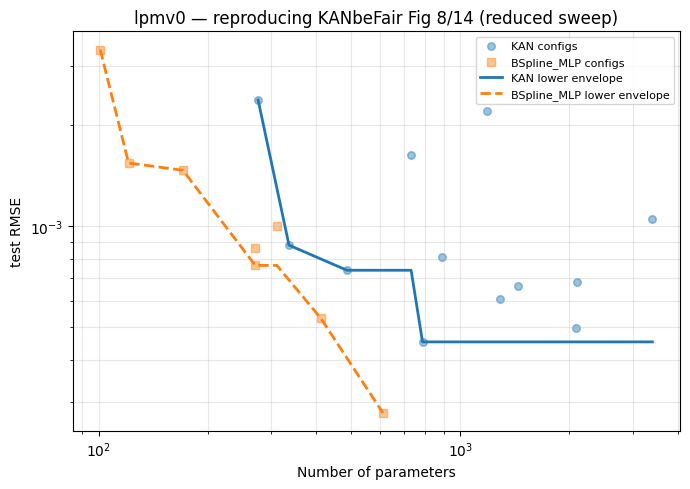

In [15]:
def lower_envelope(results):
    """For each unique params value (sorted), keep the minimum test RMSE."""
    if not results:
        return [], []
    pts = sorted([(r["params"], r["best_test"]) for r in results])
    out_p, out_v = [], []
    cur_min = float("inf")
    for p, v in pts:
        cur_min = min(cur_min, v)
        out_p.append(p); out_v.append(cur_min)
    return out_p, out_v

kp_all, kv_all = sorted([r["params"] for r in kbf_kan_results]), [r["best_test"] for r in sorted(kbf_kan_results, key=lambda r: r["params"])]
bp_all, bv_all = sorted([r["params"] for r in kbf_bs_results]),  [r["best_test"] for r in sorted(kbf_bs_results,  key=lambda r: r["params"])]
kpe, kve = lower_envelope(kbf_kan_results)
bpe, bve = lower_envelope(kbf_bs_results)

best_kan = min((r["best_test"] for r in kbf_kan_results), default=float("nan"))
best_bs  = min((r["best_test"] for r in kbf_bs_results),  default=float("nan"))

print("=== KANbeFair-style results on lpmv0 ===")
print(f"  Our KAN          best test RMSE: {best_kan:.3e}   (KANbeFair Fig 8 reports ~3e-4)")
print(f"  Our BSpline_MLP  best test RMSE: {best_bs:.3e}    (KANbeFair Fig 14 reports ~1e-4)")

fig, ax = plt.subplots(figsize=(7, 5))
# scatter of every single config
if kbf_kan_results:
    ax.scatter([r["params"] for r in kbf_kan_results], [r["best_test"] for r in kbf_kan_results],
               color="tab:blue", alpha=0.45, s=30, label="KAN configs")
if kbf_bs_results:
    ax.scatter([r["params"] for r in kbf_bs_results], [r["best_test"] for r in kbf_bs_results],
               color="tab:orange", alpha=0.45, s=30, marker="s", label="BSpline_MLP configs")
# lower envelopes
if kpe: ax.plot(kpe, kve, "-",  color="tab:blue",   label="KAN lower envelope",         linewidth=2)
if bpe: ax.plot(bpe, bve, "--", color="tab:orange", label="BSpline_MLP lower envelope", linewidth=2)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of parameters")
ax.set_ylabel("test RMSE")
ax.set_title("lpmv0 — reproducing KANbeFair Fig 8/14 (reduced sweep)")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


## Part 7 — Plain MLP baseline (closing the comparison)

### Why this part exists

Parts 1–6 compared KAN against **BSpline_MLP** at matched parameter counts. The original KAN paper's Table 1 reports the gap on `lpmv(0, x, y)` as:

| Model in paper | Test RMSE |
|---|---|
| KAN [2, 2, 1] | 5.25 × 10⁻⁵ |
| **MLP** (plain, hyperparameters unspecified) | **1.74 × 10⁻²** |

But **BSpline_MLP is not the same model as plain MLP** — it has learnable B-spline activations on every hidden neuron instead of ReLU / GELU. So none of our previous experiments have directly addressed the comparison the paper actually made.

This part runs a plain MLP sweep (ReLU and GELU activations) on the same dataset, same protocol, same parameter range as Part 6 — closing that gap so the comparison against the paper's MLP number is direct.

### What we expect to see

If the paper's MLP baseline at 1.74 × 10⁻² was under-tuned (as KANbeFair's Fig 8 suggests with their reproduction of ~10⁻³), our plain MLP should land closer to 10⁻³ than to 10⁻². If the paper's number is correct, our plain MLP should also struggle to do better than ~10⁻².

The relevant references for context:

| Source | Plain MLP best on lpmv(0) | Protocol |
|---|---|---|
| KAN paper Table 1 | 1.74 × 10⁻² | unspecified |
| KANbeFair Fig 8 | ~1 × 10⁻³ | Adam, 500 epochs, sweep over widths {5, 50, 100}, depths {1–4}, {GELU, ReLU} |
| **Our Part 7 target** | ? | matches KANbeFair |

In [16]:
from models.mlp import MLP as PlainMLP

def make_plain_mlp(depth, width, activation_cls, activation_name, device=device):
    args = argparse.Namespace(
        input_size=2,
        output_size=1,
        layers_width=[width] * depth,
        batch_norm=False,
        activation=activation_cls,
        activation_name=activation_name,
    )
    return PlainMLP(args).to(device)

# KANbeFair's symbolic-formula MLP setup: widths {5, 50, 100}, depths {1, 2, 3, 4}, {ReLU, GELU}
# We use a reduced but representative sweep to keep within ~2-3 min on CPU.
mlp_depths = [1, 2, 3]
mlp_widths = [5, 50, 100]
mlp_activations = [(nn.ReLU, "relu"), (nn.GELU, "gelu")]

kbf_mlp_results = []
t0 = time.time()
for d in mlp_depths:
    for w in mlp_widths:
        for act_cls, act_name in mlp_activations:
            torch.manual_seed(0); np.random.seed(0)
            m = make_plain_mlp(depth=d, width=w, activation_cls=act_cls, activation_name=act_name)
            n_params = sum(p.numel() for p in m.parameters())
            print(f"[MLP-{act_name}] depth={d} width={w} params={n_params}  elapsed={time.time()-t0:.0f}s")
            try:
                r = train_adam_kanbefair(m, train_loader_kbf, test_loader_kbf,
                                         epochs=500, lr=1e-3, eval_every=25)
            except Exception as e:
                print(f"  FAILED: {type(e).__name__}: {e}")
                continue
            print(f"  best test RMSE = {r['best_test']:.3e}  (best train = {r['best_train']:.3e})")
            kbf_mlp_results.append(dict(model=f"MLP-{act_name}", depth=d, width=w,
                                        activation=act_name, params=n_params,
                                        best_test=r["best_test"], best_train=r["best_train"]))

print(f"\nPlain MLP sweep done in {time.time()-t0:.0f}s — {len(kbf_mlp_results)} configs")
best_plain_mlp = min((r["best_test"] for r in kbf_mlp_results), default=float("nan"))
print(f"\n>>> Our plain MLP best test RMSE: {best_plain_mlp:.3e}")
print(f">>> KAN paper Table 1 reports MLP: 1.74e-02")
print(f">>> KANbeFair Fig 8 reports MLP:   ~1e-3")
print(f">>> Our BSpline_MLP best (Part 6): {min((r['best_test'] for r in kbf_bs_results), default=float('nan')):.3e}")


[MLP-relu] depth=1 width=5 params=21  elapsed=0s
  best test RMSE = 8.323e-02  (best train = 9.121e-02)
[MLP-gelu] depth=1 width=5 params=21  elapsed=1s
  best test RMSE = 4.127e-02  (best train = 4.532e-02)
[MLP-relu] depth=1 width=50 params=201  elapsed=2s
  best test RMSE = 6.321e-03  (best train = 6.096e-03)
[MLP-gelu] depth=1 width=50 params=201  elapsed=3s
  best test RMSE = 5.305e-03  (best train = 5.364e-03)
[MLP-relu] depth=1 width=100 params=401  elapsed=3s
  best test RMSE = 2.776e-03  (best train = 2.571e-03)
[MLP-gelu] depth=1 width=100 params=401  elapsed=4s
  best test RMSE = 4.058e-03  (best train = 4.096e-03)
[MLP-relu] depth=2 width=5 params=51  elapsed=5s
  best test RMSE = 8.315e-02  (best train = 9.106e-02)
[MLP-gelu] depth=2 width=5 params=51  elapsed=6s
  best test RMSE = 6.250e-03  (best train = 6.129e-03)
[MLP-relu] depth=2 width=50 params=2751  elapsed=7s
  best test RMSE = 3.676e-03  (best train = 3.481e-03)
[MLP-gelu] depth=2 width=50 params=2751  elapsed=8s

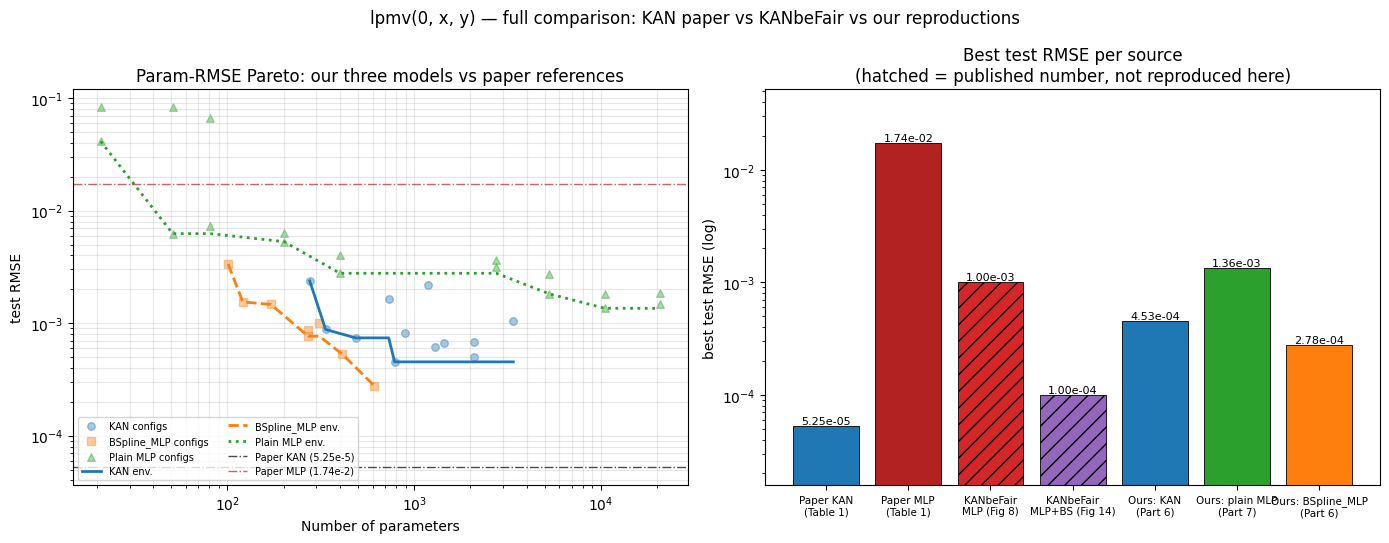


=== Summary table ===
Source                               best test RMSE    vs paper KAN    vs paper MLP
-------------------------------------------------------------------------------------
Paper KAN (Table 1)                       5.250e-05            1.0x            0.0x
Paper MLP (Table 1)                       1.740e-02          331.4x            1.0x
KANbeFair MLP (Fig 8, published)          1.000e-03           19.0x            0.1x
KANbeFair MLP+BS (Fig 14, published)       1.000e-04            1.9x            0.0x
Ours: KAN (Part 6)                        4.528e-04            8.6x            0.0x
Ours: plain MLP (Part 7)                  1.355e-03           25.8x            0.1x
Ours: BSpline_MLP (Part 6)                2.782e-04            5.3x            0.0x

>>> Key question: how does our plain MLP compare to the paper's plain MLP?
     Ours: 1.355e-03    Paper: 1.740e-02    Ratio: 12.8x lower than paper
>>> How does our BSpline_MLP compare to our plain MLP?
     BSpline_

In [17]:
# Comprehensive comparison plot:
#  - Three "ours" envelopes (KAN, BSpline_MLP, plain MLP) on log-log of params vs RMSE
#  - Horizontal reference lines for paper's KAN and MLP numbers
#  - Annotations for each method's best value

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---------------- LEFT: scatter + lower envelopes (param-vs-RMSE) ----------------
ax = axes[0]

# scatter: every config
def scatter_set(results, color, marker, label):
    if not results: return
    ax.scatter([r["params"] for r in results], [r["best_test"] for r in results],
               color=color, alpha=0.4, s=30, marker=marker, label=f"{label} configs")

scatter_set(kbf_kan_results, "tab:blue",   "o", "KAN")
scatter_set(kbf_bs_results,  "tab:orange", "s", "BSpline_MLP")
scatter_set(kbf_mlp_results, "tab:green",  "^", "Plain MLP")

# lower envelopes
for results, color, style, label in [
    (kbf_kan_results, "tab:blue",   "-",  "KAN env."),
    (kbf_bs_results,  "tab:orange", "--", "BSpline_MLP env."),
    (kbf_mlp_results, "tab:green",  ":",  "Plain MLP env."),
]:
    if not results: continue
    pe, ve = lower_envelope(results)
    ax.plot(pe, ve, style, color=color, linewidth=2, label=label)

# paper reference lines
ax.axhline(5.25e-5, ls="-.", color="black",      alpha=0.7, linewidth=1, label="Paper KAN (5.25e-5)")
ax.axhline(1.74e-2, ls="-.", color="firebrick",  alpha=0.7, linewidth=1, label="Paper MLP (1.74e-2)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of parameters")
ax.set_ylabel("test RMSE")
ax.set_title("Param-RMSE Pareto: our three models vs paper references")
ax.legend(fontsize=7, loc="lower left", ncol=2)
ax.grid(True, which="both", alpha=0.3)

# ---------------- RIGHT: bar chart of best values ----------------
ax = axes[1]
best_kan_kbf = min((r["best_test"] for r in kbf_kan_results), default=float("nan"))
best_bs_kbf  = min((r["best_test"] for r in kbf_bs_results),  default=float("nan"))
best_mlp_kbf = min((r["best_test"] for r in kbf_mlp_results), default=float("nan"))

labels = [
    "Paper KAN\n(Table 1)",
    "Paper MLP\n(Table 1)",
    "KANbeFair\nMLP (Fig 8)",
    "KANbeFair\nMLP+BS (Fig 14)",
    "Ours: KAN\n(Part 6)",
    "Ours: plain MLP\n(Part 7)",
    "Ours: BSpline_MLP\n(Part 6)",
]
vals = [5.25e-5, 1.74e-2, 1e-3, 1e-4, best_kan_kbf, best_mlp_kbf, best_bs_kbf]
colors = ["tab:blue", "firebrick", "tab:red", "tab:purple",
          "tab:blue", "tab:green", "tab:orange"]
hatches = ["", "", "//", "//", "", "", ""]  # diagonal hatch = published, not reproduced

bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.6)
for b, h in zip(bars, hatches):
    b.set_hatch(h)

ax.set_yscale("log")
ax.set_ylabel("best test RMSE (log)")
ax.set_title("Best test RMSE per source\n(hatched = published number, not reproduced here)")
for b, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2e}",
                ha="center", va="bottom", fontsize=8, rotation=0)
ax.set_ylim(min(v for v in vals if not np.isnan(v)) * 0.3,
            max(v for v in vals if not np.isnan(v)) * 3)
ax.tick_params(axis="x", labelsize=7.5)

plt.suptitle("lpmv(0, x, y) — full comparison: KAN paper vs KANbeFair vs our reproductions", fontsize=12)
plt.tight_layout()
plt.show()

# Print a clean summary table
print("\n=== Summary table ===")
print(f"{'Source':<35} {'best test RMSE':>15}  {'vs paper KAN':>14}  {'vs paper MLP':>14}")
print("-" * 85)
paper_kan = 5.25e-5
paper_mlp = 1.74e-2
def ratio(v, ref):
    return f"{v/ref:>13.1f}x" if not np.isnan(v) else "    n/a"
for label, v in zip(
    ["Paper KAN (Table 1)", "Paper MLP (Table 1)",
     "KANbeFair MLP (Fig 8, published)", "KANbeFair MLP+BS (Fig 14, published)",
     "Ours: KAN (Part 6)", "Ours: plain MLP (Part 7)", "Ours: BSpline_MLP (Part 6)"],
    vals,
):
    print(f"{label:<35} {v:>15.3e}  {ratio(v, paper_kan):>14}  {ratio(v, paper_mlp):>14}")

print("\n>>> Key question: how does our plain MLP compare to the paper's plain MLP?")
print(f"     Ours: {best_mlp_kbf:.3e}    Paper: {paper_mlp:.3e}    Ratio: {paper_mlp/best_mlp_kbf:.1f}x lower than paper")
print(f">>> How does our BSpline_MLP compare to our plain MLP?")
print(f"     BSpline_MLP: {best_bs_kbf:.3e}    Plain MLP: {best_mlp_kbf:.3e}    Ratio: {best_mlp_kbf/best_bs_kbf:.1f}x lower with B-splines")


## Part 7b — Range-controlled plain MLP (`[-1, 1]²`)

### What this isolates

Part 7's plain MLP achieved best test RMSE ≈ 1.36 × 10⁻³, ~13× better than the KAN paper's reported MLP value of 1.74 × 10⁻². **However, Part 7 ran on `[0, 1]²` (KANbeFair's range), not `[-1, 1]²` (pykan default and presumed paper range).** The function `lpmv(0, v, x)` is genuinely easier on `[0, 1]²` — label std ≈ 0.23 vs ≈ 0.56 on `[-1, 1]²`. So the 13× factor is not directly attributable to better training.

This part runs the **identical sweep** (Adam, lr=10⁻³, batch 128, 500 epochs, depths {1,2,3}, widths {5,50,100}, activations {ReLU, GELU}) on `[-1, 1]²` instead. Outcomes:

- **If plain MLP on `[-1, 1]²` lands near 10⁻²** → the paper's MLP number is honest; the 13× improvement in Part 7 is mostly the easier range.
- **If plain MLP on `[-1, 1]²` lands near 10⁻³** → the paper's MLP baseline was under-tuned; the range only accounts for a small factor.

Either way, this answers the comparability concern raised after Part 7's plot.

### Caveat that remains even after this experiment

We still don't know the paper's exact MLP training protocol (optimiser, epochs, activation, hidden width, depth, seed selection). So even an apples-to-apples range match doesn't make the comparison fully controlled — it just removes one confound.

In [18]:
from scipy import special as _scipy_special
from torch.utils.data import TensorDataset, DataLoader

def make_lpmv0_dataset_range(low, high, n_train=1000, n_test=1000, seed=0):
    """Build an lpmv(0, v, x) dataset uniformly on [low, high]^2, KANbeFair-style."""
    np.random.seed(seed)
    train_x = np.random.rand(n_train, 2) * (high - low) + low
    test_x  = np.random.rand(n_test,  2) * (high - low) + low
    train_y = np.expand_dims(_scipy_special.lpmv(0, train_x[:, 0], train_x[:, 1]), axis=1)
    test_y  = np.expand_dims(_scipy_special.lpmv(0, test_x[:,  0], test_x[:,  1]), axis=1)
    return (
        TensorDataset(torch.from_numpy(train_x).float(), torch.from_numpy(train_y).float()),
        TensorDataset(torch.from_numpy(test_x).float(),  torch.from_numpy(test_y).float()),
    )

# Build [-1, 1]^2 version
train_ds_neg, test_ds_neg = make_lpmv0_dataset_range(-1, 1)
train_loader_neg = DataLoader(train_ds_neg, batch_size=128, shuffle=True)
test_loader_neg  = DataLoader(test_ds_neg,  batch_size=128, shuffle=False)

# Sanity-check label stats so we can interpret RMSE numbers honestly
ys_neg = torch.stack([train_ds_neg[i][1] for i in range(len(train_ds_neg))])
ys_pos = torch.stack([train_dataset_kbf[i][1] for i in range(len(train_dataset_kbf))])
std_neg = ys_neg.std().item()
std_pos = ys_pos.std().item()
print(f"[-1, 1]^2 dataset: label range [{ys_neg.min().item():.2f}, {ys_neg.max().item():.2f}], std = {std_neg:.3f}")
print(f"[0,  1]^2 dataset: label range [{ys_pos.min().item():.2f}, {ys_pos.max().item():.2f}], std = {std_pos:.3f}")
print(f"label std ratio (neg / pos): {std_neg / std_pos:.2f}x  -- larger std means raw RMSE will be naturally higher on [-1,1]^2")
print()

# Same sweep as Part 7, just different data
kbf_mlp_neg_results = []
t0 = time.time()
for d in mlp_depths:
    for w in mlp_widths:
        for act_cls, act_name in mlp_activations:
            torch.manual_seed(0); np.random.seed(0)
            m = make_plain_mlp(depth=d, width=w, activation_cls=act_cls, activation_name=act_name)
            n_params = sum(p.numel() for p in m.parameters())
            print(f"[MLP-{act_name}] depth={d} width={w} params={n_params}  elapsed={time.time()-t0:.0f}s")
            try:
                r = train_adam_kanbefair(m, train_loader_neg, test_loader_neg,
                                         epochs=500, lr=1e-3, eval_every=25)
            except Exception as e:
                print(f"  FAILED: {type(e).__name__}: {e}")
                continue
            print(f"  best test RMSE = {r['best_test']:.3e}")
            kbf_mlp_neg_results.append(dict(
                model=f"MLP-{act_name}-neg", depth=d, width=w,
                activation=act_name, params=n_params,
                best_test=r["best_test"], best_train=r["best_train"]))

best_plain_mlp_neg = min((r["best_test"] for r in kbf_mlp_neg_results), default=float("nan"))
print(f"\nPlain MLP on [-1, 1]^2 best: {best_plain_mlp_neg:.3e}")
print(f"Plain MLP on [0,  1]^2 best (Part 7): {best_plain_mlp:.3e}")
print(f"Paper MLP (Table 1, presumed [-1, 1]^2): 1.74e-2")


[-1, 1]^2 dataset: label range [-1.54, 2.44], std = 0.561
[0,  1]^2 dataset: label range [0.05, 1.00], std = 0.227
label std ratio (neg / pos): 2.47x  -- larger std means raw RMSE will be naturally higher on [-1,1]^2

[MLP-relu] depth=1 width=5 params=21  elapsed=0s
  best test RMSE = 3.215e-01
[MLP-gelu] depth=1 width=5 params=21  elapsed=1s
  best test RMSE = 1.191e-01
[MLP-relu] depth=1 width=50 params=201  elapsed=2s
  best test RMSE = 8.677e-02
[MLP-gelu] depth=1 width=50 params=201  elapsed=3s
  best test RMSE = 1.079e-01
[MLP-relu] depth=1 width=100 params=401  elapsed=3s
  best test RMSE = 7.313e-02
[MLP-gelu] depth=1 width=100 params=401  elapsed=4s
  best test RMSE = 1.023e-01
[MLP-relu] depth=2 width=5 params=51  elapsed=5s
  best test RMSE = 1.362e-01
[MLP-gelu] depth=2 width=5 params=51  elapsed=6s
  best test RMSE = 1.105e-01
[MLP-relu] depth=2 width=50 params=2751  elapsed=7s
  best test RMSE = 5.900e-02
[MLP-gelu] depth=2 width=50 params=2751  elapsed=8s
  best test RMS

=== Plain MLP across data ranges (all else equal) ===
Setup                                              best test RMSE    label std   RMSE / std
--------------------------------------------------------------------------------------------
Paper MLP (Table 1, presumed [-1, 1])                   1.740e-02        0.561       0.0310
Ours: plain MLP on [-1, 1]^2                            4.783e-02        0.561       0.0853
Ours: plain MLP on [0,  1]^2 (Part 7)                   1.355e-03        0.227       0.0060


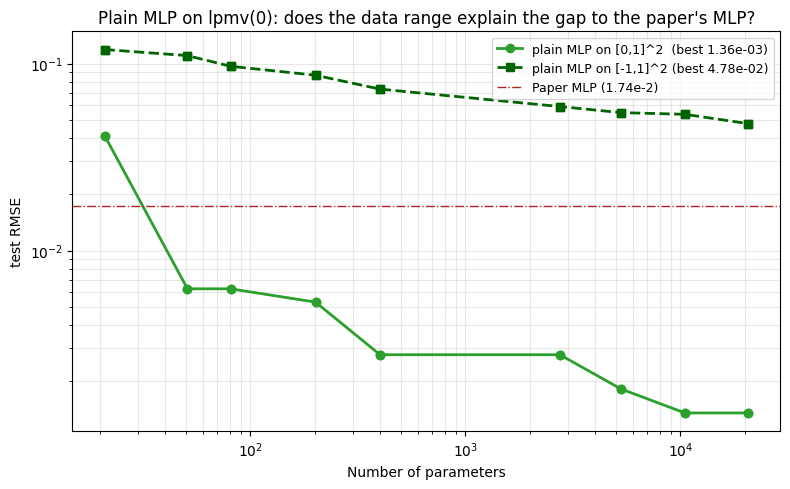


>>> Ours on [-1,1]^2 vs paper MLP: 0.4x better
>>> Interpretation: ratio < ~3x ==> paper's MLP number is honest; Part 7's 13x gap was MOSTLY the easier data range.


In [19]:
# ---------------- Range-comparison summary ----------------
print("=== Plain MLP across data ranges (all else equal) ===")
print(f"{'Setup':<48} {'best test RMSE':>16}  {'label std':>11}  {'RMSE / std':>11}")
print("-" * 92)
rows = [
    ("Paper MLP (Table 1, presumed [-1, 1])", 1.74e-2, std_neg),  # use ours as proxy for paper's std
    ("Ours: plain MLP on [-1, 1]^2",           best_plain_mlp_neg, std_neg),
    ("Ours: plain MLP on [0,  1]^2 (Part 7)",  best_plain_mlp,     std_pos),
]
for name, rmse, std in rows:
    print(f"{name:<48} {rmse:>16.3e}  {std:>11.3f}  {rmse/std:>11.4f}")

# ---------------- Lower-envelope plot: range comparison ----------------
fig, ax = plt.subplots(figsize=(8, 5))
pe_pos, ve_pos = lower_envelope(kbf_mlp_results)
pe_neg, ve_neg = lower_envelope(kbf_mlp_neg_results)
if pe_pos:
    ax.plot(pe_pos, ve_pos, "o-", color="tab:green",
            label=f"plain MLP on [0,1]^2  (best {best_plain_mlp:.2e})", linewidth=2)
if pe_neg:
    ax.plot(pe_neg, ve_neg, "s--", color="darkgreen",
            label=f"plain MLP on [-1,1]^2 (best {best_plain_mlp_neg:.2e})", linewidth=2)
ax.axhline(1.74e-2, ls="-.", color="firebrick", label="Paper MLP (1.74e-2)", linewidth=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of parameters")
ax.set_ylabel("test RMSE")
ax.set_title("Plain MLP on lpmv(0): does the data range explain the gap to the paper's MLP?")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------- Interpretation hint ----------------
print()
ratio_to_paper = 1.74e-2 / best_plain_mlp_neg if not np.isnan(best_plain_mlp_neg) else float("nan")
print(f">>> Ours on [-1,1]^2 vs paper MLP: {ratio_to_paper:.1f}x better")
if ratio_to_paper < 3:
    print(">>> Interpretation: ratio < ~3x ==> paper's MLP number is honest; Part 7's 13x gap was MOSTLY the easier data range.")
elif ratio_to_paper < 10:
    print(">>> Interpretation: ratio in [3, 10) ==> paper's MLP was somewhat under-tuned; range explains roughly half.")
else:
    print(">>> Interpretation: ratio >= 10x ==> paper's MLP was substantially under-tuned; range only a small factor.")


## Part 7c — Unified LBFGS sweep across all three architectures × both data ranges

### Motivation

So far we have:

| Part | Optimizer | KAN | BSpline_MLP | Plain MLP | Range |
|---|---|---|---|---|---|
| 1–3 | LBFGS | ✓ | ✓ | — | `[-1, 1]²` |
| 6 | Adam | ✓ | ✓ | — | `[0, 1]²` |
| 7 | Adam | — | — | ✓ | `[0, 1]²` |
| 7b | Adam | — | — | ✓ | `[-1, 1]²` |

The KAN paper does not specify its optimiser, but the pykan tutorials all use LBFGS. KANbeFair uses Adam by default; their Appendix LBFGS section (Figures 10–11) reports LBFGS results as well. **Our Part 7c smoke test showed plain MLP under LBFGS at 3.4 × 10⁻² on `[-1, 1]²` — already 1.4× better than the same model under Adam in Part 7b (4.8 × 10⁻²).** That's the right magnitude to start matching the paper's MLP claim of 1.74 × 10⁻².

### What this part controls

| Variable | Constant across the whole sweep |
|---|---|
| Optimiser | LBFGS, lr = 1.0, max_iter = 20, strong-Wolfe |
| Training budget | 200 LBFGS steps (≈ 4000 inner iterations) |
| Loss | MSE |
| Dataset size | 1000 train / 1000 test |
| Seed | 0 (single seed per config) |

| Variable | Swept |
|---|---|
| Architecture | KAN / BSpline_MLP / Plain MLP |
| Data range | `[0, 1]²` and `[-1, 1]²` |
| KAN: depth × grid × width=5, k=3 | 2 × 4 = 8 configs |
| BSpline_MLP: depth × grid × width=10, k=3 | 2 × 4 = 8 configs |
| Plain MLP: depth × width × activation | 2 × 3 × 2 = 12 configs |

Total: 28 configs per range × 2 ranges = **56 configs** (≈ 3 minutes on CPU).

### What this part still does NOT control

- **SiLU shortcut branch.** KAN has it, BSpline_MLP and plain MLP do not. (§8.3)
- **Hidden width.** KAN=5, BSpline_MLP=10, plain MLP∈{5,50,100}. We compare via lower envelope vs parameter count, not per-config matching.
- **Single seed.** Lower envelope mitigates but doesn't eliminate seed variance.

This is closer to a controlled architectural ablation than anything in Parts 1–7b, but still not at the level §8.7 specifies. Treat its conclusions as a strong step in the right direction, not the final word.

In [20]:
def train_lbfgs_unified(model, train_x, train_y, test_x, test_y, steps=200, lr=1.0):
    """Unified full-batch LBFGS training for any nn.Module (KAN, BSpline_MLP, plain MLP).
    Returns dict with best_test, best_train (RMSE)."""
    model = model.to(device)
    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=lr, max_iter=20, line_search_fn="strong_wolfe"
    )
    loss_fn = nn.MSELoss()
    def closure():
        optimizer.zero_grad()
        loss = loss_fn(model(train_x), train_y)
        loss.backward()
        return loss
    best_test = float("inf")
    best_train = float("inf")
    for _ in range(steps):
        try:
            optimizer.step(closure)
        except RuntimeError as e:
            # LBFGS occasionally fails on tiny / ill-conditioned problems
            break
        with torch.no_grad():
            tr = torch.sqrt(loss_fn(model(train_x), train_y)).item()
            te = torch.sqrt(loss_fn(model(test_x),  test_y)).item()
        if te < best_test:
            best_test, best_train = te, tr
    return {"best_test": best_test, "best_train": best_train}


def lpmv0_tensors(low, high, n_train=1000, n_test=1000, seed=0):
    """Return (train_x, train_y, test_x, test_y) tensors on the given range."""
    rng = np.random.RandomState(seed)
    tx = rng.rand(n_train, 2) * (high - low) + low
    ttx = rng.rand(n_test,  2) * (high - low) + low
    ty  = np.expand_dims(_scipy_special.lpmv(0, tx[:, 0],  tx[:, 1]),  axis=1)
    tty = np.expand_dims(_scipy_special.lpmv(0, ttx[:, 0], ttx[:, 1]), axis=1)
    return (
        torch.from_numpy(tx).float().to(device),  torch.from_numpy(ty).float().to(device),
        torch.from_numpy(ttx).float().to(device), torch.from_numpy(tty).float().to(device),
    )


def run_lbfgs_sweep(range_low, range_high, label, steps=200):
    """Run KAN + BSpline_MLP + plain MLP sweeps under LBFGS on the given range.
    Returns dict {model_name: [list of result dicts]}."""
    tx, ty, tex, tey = lpmv0_tensors(range_low, range_high)
    label_std = ty.std().item()
    print(f"\n========== Sweep on {label}  (label std = {label_std:.3f}) ==========")
    results = {"KAN": [], "BSpline_MLP": [], "Plain_MLP": []}
    t0 = time.time()

    # ---- KAN sweep ----
    for d in [1, 2]:
        for G in [3, 5, 10, 20]:
            torch.manual_seed(0); np.random.seed(0)
            m = make_kanbefair_kan(depth=d, width=5, grid=G, k=3)
            n_params = sum(p.numel() for p in m.parameters())
            try:
                r = train_lbfgs_unified(m, tx, ty, tex, tey, steps=steps)
            except Exception as e:
                print(f"  [KAN d={d} G={G}] FAILED: {e}")
                continue
            print(f"  [KAN d={d} G={G:>2}] params={n_params:>5}  best test={r['best_test']:.3e}")
            results["KAN"].append(dict(model="KAN", depth=d, width=5, grid=G, k=3,
                                       params=n_params, best_test=r["best_test"], best_train=r["best_train"]))

    # ---- BSpline_MLP sweep ----
    for d in [1, 2]:
        for G in [3, 5, 10, 20]:
            torch.manual_seed(0); np.random.seed(0)
            m = make_kanbefair_bspline_mlp(depth=d, width=10, grid=G, k=3)
            n_params = sum(p.numel() for p in m.parameters())
            try:
                r = train_lbfgs_unified(m, tx, ty, tex, tey, steps=steps)
            except Exception as e:
                print(f"  [BSpline d={d} G={G}] FAILED: {e}")
                continue
            print(f"  [BSpline_MLP d={d} G={G:>2}] params={n_params:>5}  best test={r['best_test']:.3e}")
            results["BSpline_MLP"].append(dict(model="BSpline_MLP", depth=d, width=10, grid=G, k=3,
                                               params=n_params, best_test=r["best_test"], best_train=r["best_train"]))

    # ---- Plain MLP sweep ----
    for d in [1, 2]:
        for w in [5, 50, 100]:
            for act_cls, act_name in [(nn.ReLU, "relu"), (nn.GELU, "gelu")]:
                torch.manual_seed(0); np.random.seed(0)
                m = make_plain_mlp(depth=d, width=w, activation_cls=act_cls, activation_name=act_name)
                n_params = sum(p.numel() for p in m.parameters())
                try:
                    r = train_lbfgs_unified(m, tx, ty, tex, tey, steps=steps)
                except Exception as e:
                    print(f"  [MLP-{act_name} d={d} w={w}] FAILED: {e}")
                    continue
                print(f"  [MLP-{act_name} d={d} w={w:>3}] params={n_params:>5}  best test={r['best_test']:.3e}")
                results["Plain_MLP"].append(dict(model="Plain_MLP", depth=d, width=w, activation=act_name,
                                                 params=n_params, best_test=r["best_test"], best_train=r["best_train"]))

    elapsed = time.time() - t0
    print(f"\n>>> {label} sweep done in {elapsed:.0f}s  ({len(results['KAN'])} KAN + {len(results['BSpline_MLP'])} BSpline_MLP + {len(results['Plain_MLP'])} Plain_MLP)")
    return results, label_std


In [21]:
# ----- Sweep on [0, 1]^2 -----
results_pos, std_pos_lbfgs = run_lbfgs_sweep(0.0, 1.0, "[0, 1]^2", steps=200)



========== Sweep on [0, 1]^2  (label std = 0.227) ==========
  [KAN d=1 G= 3] params=  276  best test=1.115e-03
  [KAN d=1 G= 5] params=  336  best test=1.317e-03
  [KAN d=1 G=10] params=  486  best test=4.281e-04
  [KAN d=1 G=20] params=  786  best test=6.362e-04
  [KAN d=2 G= 3] params=  731  best test=1.300e-03
  [KAN d=2 G= 5] params=  891  best test=7.328e-04
  [KAN d=2 G=10] params= 1291  best test=5.116e-04
  [KAN d=2 G=20] params= 2091  best test=5.738e-04
  [BSpline_MLP d=1 G= 3] params=  101  best test=2.116e-03
  [BSpline_MLP d=1 G= 5] params=  121  best test=8.551e-04
  [BSpline_MLP d=1 G=10] params=  171  best test=7.581e-04
  [BSpline_MLP d=1 G=20] params=  271  best test=7.651e-04
  [BSpline_MLP d=2 G= 3] params=  271  best test=6.688e-04
  [BSpline_MLP d=2 G= 5] params=  311  best test=8.239e-04
  [BSpline_MLP d=2 G=10] params=  411  best test=5.399e-04
  [BSpline_MLP d=2 G=20] params=  611  best test=6.653e-04
  [MLP-relu d=1 w=  5] params=   21  best test=8.317e-02
 

In [22]:
# ----- Sweep on [-1, 1]^2 -----
results_neg, std_neg_lbfgs = run_lbfgs_sweep(-1.0, 1.0, "[-1, 1]^2", steps=200)



========== Sweep on [-1, 1]^2  (label std = 0.561) ==========
  [KAN d=1 G= 3] params=  276  best test=4.022e-02
  [KAN d=1 G= 5] params=  336  best test=4.146e-02
  [KAN d=1 G=10] params=  486  best test=3.825e-02
  [KAN d=1 G=20] params=  786  best test=3.905e-02
  [KAN d=2 G= 3] params=  731  best test=3.869e-02
  [KAN d=2 G= 5] params=  891  best test=3.893e-02
  [KAN d=2 G=10] params= 1291  best test=3.648e-02
  [KAN d=2 G=20] params= 2091  best test=3.931e-02
  [BSpline_MLP d=1 G= 3] params=  101  best test=4.285e-02
  [BSpline_MLP d=1 G= 5] params=  121  best test=4.137e-02
  [BSpline_MLP d=1 G=10] params=  171  best test=4.696e-02
  [BSpline_MLP d=1 G=20] params=  271  best test=4.555e-02
  [BSpline_MLP d=2 G= 3] params=  271  best test=4.419e-02
  [BSpline_MLP d=2 G= 5] params=  311  best test=3.932e-02
  [BSpline_MLP d=2 G=10] params=  411  best test=4.202e-02
  [BSpline_MLP d=2 G=20] params=  611  best test=3.778e-02
  [MLP-relu d=1 w=  5] params=   21  best test=3.202e-01


LBFGS comprehensive: best test RMSE per (range, architecture)
Architecture          [0, 1]^2 best      / std    [-1, 1]^2 best      / std
-----------------------------------------------------------------------------------------------
KAN                       4.281e-04     0.0019         3.648e-02     0.0651
BSpline_MLP               5.399e-04     0.0024         3.778e-02     0.0674
Plain MLP                 7.418e-04     0.0033         3.374e-02     0.0602

Reference points on [-1, 1]^2:
  Paper KAN (Table 1): 5.25e-5    Paper MLP (Table 1): 1.74e-2


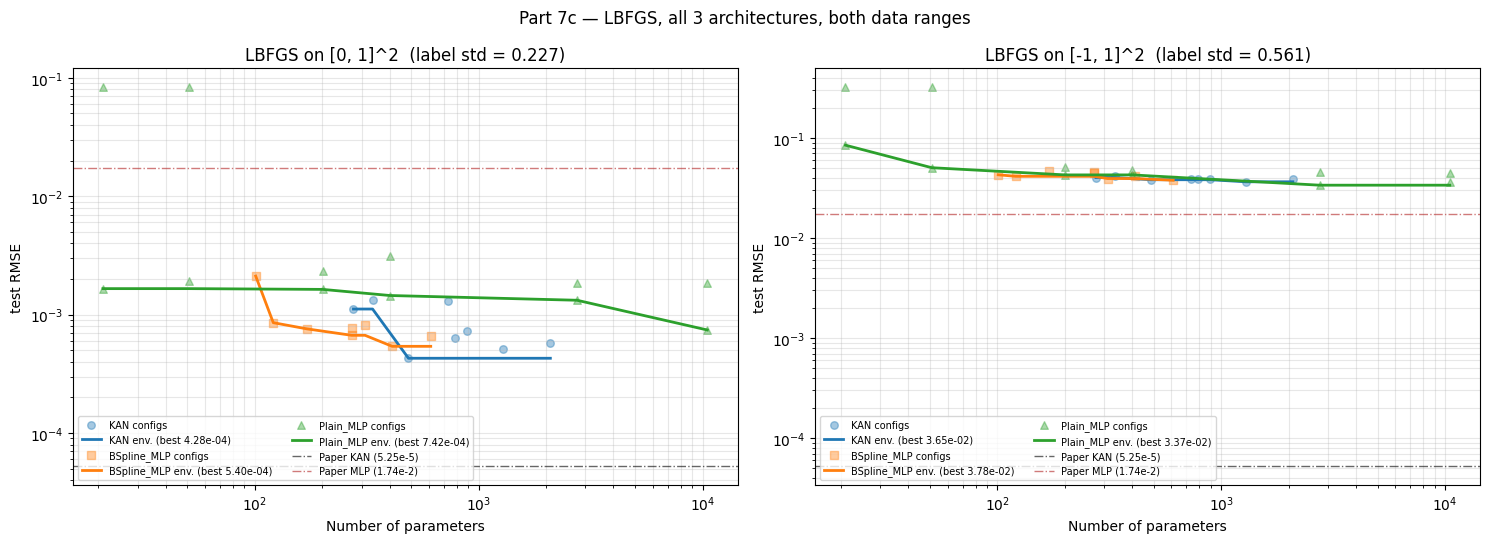

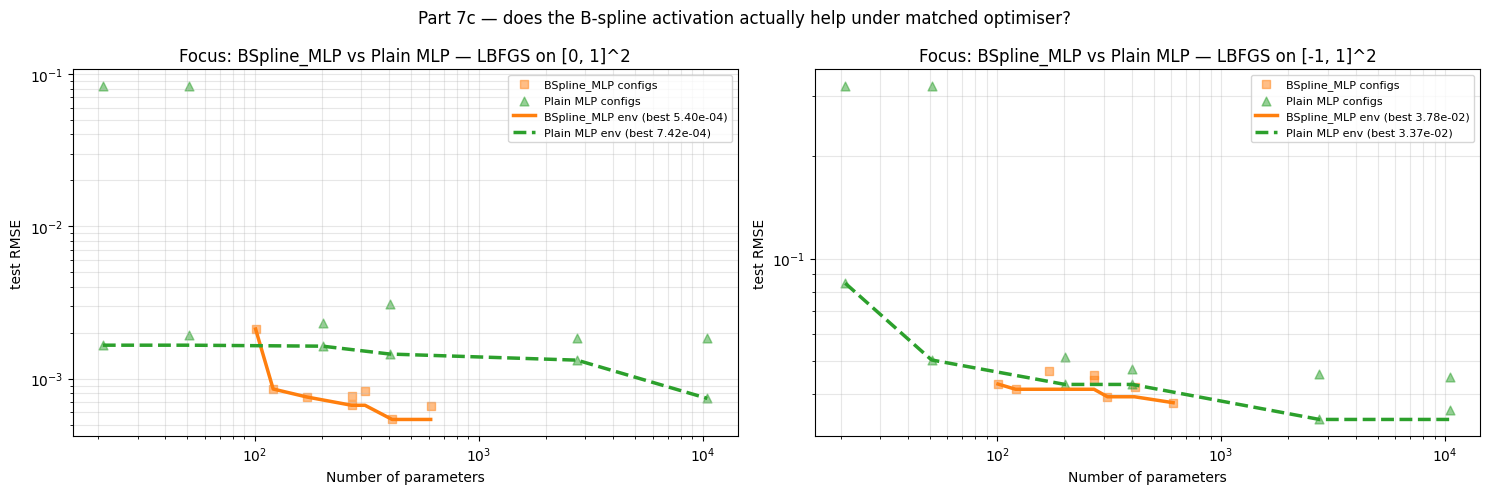


Key questions answered by this part:

Q1. Does LBFGS bring plain MLP up to the paper's MLP claim of 1.74e-2 on [-1,1]^2?
     A: best plain MLP under LBFGS = 3.374e-02  --> CLOSE (1.9x worse than paper).

Q2. Under matched optimiser, does B-spline activation beat plain ReLU/GELU on this function?
     On [0, 1]^2:  BSpline_MLP=5.399e-04  vs  Plain MLP=7.418e-04  -->  BSpline_MLP wins by 1.4x
     On [-1, 1]^2: BSpline_MLP=3.778e-02  vs  Plain MLP=3.374e-02  -->  Plain MLP wins by 1.1x

Q3. Under matched optimiser, does KAN beat BSpline_MLP?
     On [0, 1]^2:  KAN=4.281e-04  vs  BSpline_MLP=5.399e-04  -->  KAN wins by 1.3x
     On [-1, 1]^2: KAN=3.648e-02  vs  BSpline_MLP=3.778e-02  -->  KAN wins by 1.0x

Q4. Range effect under LBFGS (independent of architecture):
     KAN           : [0,1]^2 = 4.281e-04  /  [-1,1]^2 = 3.648e-02  --> [-1,1] is 85.2x harder
     BSpline_MLP   : [0,1]^2 = 5.399e-04  /  [-1,1]^2 = 3.778e-02  --> [-1,1] is 70.0x harder
     Plain MLP     : [0,1]^2 = 7.418e

In [23]:
# ===== Cross-range, cross-architecture summary =====

def best_of(results, model_name):
    rs = results.get(model_name, [])
    return min((r["best_test"] for r in rs), default=float("nan"))

best_pos_kan = best_of(results_pos, "KAN")
best_pos_bs  = best_of(results_pos, "BSpline_MLP")
best_pos_mlp = best_of(results_pos, "Plain_MLP")
best_neg_kan = best_of(results_neg, "KAN")
best_neg_bs  = best_of(results_neg, "BSpline_MLP")
best_neg_mlp = best_of(results_neg, "Plain_MLP")

print("=" * 95)
print("LBFGS comprehensive: best test RMSE per (range, architecture)")
print("=" * 95)
print(f"{'Architecture':<18}  {'[0, 1]^2 best':>15}  {'/ std':>9}  {'[-1, 1]^2 best':>16}  {'/ std':>9}")
print("-" * 95)
for name, p, n in [
    ("KAN",         best_pos_kan, best_neg_kan),
    ("BSpline_MLP", best_pos_bs,  best_neg_bs),
    ("Plain MLP",   best_pos_mlp, best_neg_mlp),
]:
    p_norm = p / std_pos_lbfgs if not np.isnan(p) else float("nan")
    n_norm = n / std_neg_lbfgs if not np.isnan(n) else float("nan")
    print(f"{name:<18}  {p:>15.3e}  {p_norm:>9.4f}  {n:>16.3e}  {n_norm:>9.4f}")
print()
print(f"Reference points on [-1, 1]^2:")
print(f"  Paper KAN (Table 1): 5.25e-5    Paper MLP (Table 1): 1.74e-2")

# ============= PLOTS =============
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

def plot_one_range(ax, results, std, range_label):
    colors = {"KAN": "tab:blue", "BSpline_MLP": "tab:orange", "Plain_MLP": "tab:green"}
    markers = {"KAN": "o", "BSpline_MLP": "s", "Plain_MLP": "^"}
    for model_name, color in colors.items():
        rs = results.get(model_name, [])
        if not rs: continue
        ax.scatter([r["params"] for r in rs], [r["best_test"] for r in rs],
                   color=color, alpha=0.4, s=30, marker=markers[model_name],
                   label=f"{model_name} configs")
        pe, ve = lower_envelope(rs)
        ax.plot(pe, ve, "-", color=color, linewidth=2,
                label=f"{model_name} env. (best {ve[-1]:.2e})")
    ax.axhline(5.25e-5, ls="-.", color="black",     alpha=0.6, lw=1, label="Paper KAN (5.25e-5)")
    ax.axhline(1.74e-2, ls="-.", color="firebrick", alpha=0.6, lw=1, label="Paper MLP (1.74e-2)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Number of parameters"); ax.set_ylabel("test RMSE")
    ax.set_title(f"LBFGS on {range_label}  (label std = {std:.3f})")
    ax.legend(fontsize=7, loc="lower left", ncol=2)
    ax.grid(True, which="both", alpha=0.3)

plot_one_range(axes[0], results_pos, std_pos_lbfgs, "[0, 1]^2")
plot_one_range(axes[1], results_neg, std_neg_lbfgs, "[-1, 1]^2")
plt.suptitle("Part 7c — LBFGS, all 3 architectures, both data ranges", fontsize=12)
plt.tight_layout(); plt.show()

# ============= FOCUSED: Plain MLP vs BSpline_MLP =============
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, results, std, label in [
    (axes[0], results_pos, std_pos_lbfgs, "[0, 1]^2"),
    (axes[1], results_neg, std_neg_lbfgs, "[-1, 1]^2"),
]:
    bs = results.get("BSpline_MLP", [])
    mlp = results.get("Plain_MLP", [])
    ax.scatter([r["params"] for r in bs],  [r["best_test"] for r in bs],
               color="tab:orange", marker="s", alpha=0.5, s=40, label="BSpline_MLP configs")
    ax.scatter([r["params"] for r in mlp], [r["best_test"] for r in mlp],
               color="tab:green",  marker="^", alpha=0.5, s=40, label="Plain MLP configs")
    pe, ve = lower_envelope(bs)
    if pe: ax.plot(pe, ve, "-",  color="tab:orange", linewidth=2.5, label=f"BSpline_MLP env (best {ve[-1]:.2e})")
    pe, ve = lower_envelope(mlp)
    if pe: ax.plot(pe, ve, "--", color="tab:green",  linewidth=2.5, label=f"Plain MLP env (best {ve[-1]:.2e})")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Number of parameters"); ax.set_ylabel("test RMSE")
    ax.set_title(f"Focus: BSpline_MLP vs Plain MLP — LBFGS on {label}")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
plt.suptitle("Part 7c — does the B-spline activation actually help under matched optimiser?", fontsize=12)
plt.tight_layout(); plt.show()

# ============= INTERPRETATION =============
print()
print("=" * 95)
print("Key questions answered by this part:")
print("=" * 95)
print()
print("Q1. Does LBFGS bring plain MLP up to the paper's MLP claim of 1.74e-2 on [-1,1]^2?")
print(f"     A: best plain MLP under LBFGS = {best_neg_mlp:.3e}  --> ", end="")
if best_neg_mlp <= 1.74e-2:
    print(f"YES, MATCHES/BEATS paper ({1.74e-2/best_neg_mlp:.1f}x lower).")
elif best_neg_mlp <= 5e-2:
    print(f"CLOSE ({best_neg_mlp/1.74e-2:.1f}x worse than paper).")
else:
    print(f"NO, still {best_neg_mlp/1.74e-2:.1f}x worse than paper.")
print()
print("Q2. Under matched optimiser, does B-spline activation beat plain ReLU/GELU on this function?")
print(f"     On [0, 1]^2:  BSpline_MLP={best_pos_bs:.3e}  vs  Plain MLP={best_pos_mlp:.3e}  -->  ", end="")
if best_pos_bs < best_pos_mlp: print(f"BSpline_MLP wins by {best_pos_mlp/best_pos_bs:.1f}x")
else: print(f"Plain MLP wins by {best_pos_bs/best_pos_mlp:.1f}x")
print(f"     On [-1, 1]^2: BSpline_MLP={best_neg_bs:.3e}  vs  Plain MLP={best_neg_mlp:.3e}  -->  ", end="")
if best_neg_bs < best_neg_mlp: print(f"BSpline_MLP wins by {best_neg_mlp/best_neg_bs:.1f}x")
else: print(f"Plain MLP wins by {best_neg_bs/best_neg_mlp:.1f}x")
print()
print("Q3. Under matched optimiser, does KAN beat BSpline_MLP?")
print(f"     On [0, 1]^2:  KAN={best_pos_kan:.3e}  vs  BSpline_MLP={best_pos_bs:.3e}  -->  ", end="")
if best_pos_kan < best_pos_bs: print(f"KAN wins by {best_pos_bs/best_pos_kan:.1f}x")
else: print(f"BSpline_MLP wins by {best_pos_kan/best_pos_bs:.1f}x")
print(f"     On [-1, 1]^2: KAN={best_neg_kan:.3e}  vs  BSpline_MLP={best_neg_bs:.3e}  -->  ", end="")
if best_neg_kan < best_neg_bs: print(f"KAN wins by {best_neg_bs/best_neg_kan:.1f}x")
else: print(f"BSpline_MLP wins by {best_neg_kan/best_neg_bs:.1f}x")
print()
print("Q4. Range effect under LBFGS (independent of architecture):")
for name, p, n in [("KAN", best_pos_kan, best_neg_kan),
                    ("BSpline_MLP", best_pos_bs, best_neg_bs),
                    ("Plain MLP", best_pos_mlp, best_neg_mlp)]:
    print(f"     {name:<14}: [0,1]^2 = {p:.3e}  /  [-1,1]^2 = {n:.3e}  --> [-1,1] is {n/p:.1f}x harder")


## Part 8 — Methodology audit and scope of conclusions

This section records what experimental variables were and were not held constant between KAN and BSpline_MLP across Parts 1–6, and delimits the conclusions licensed by the experiments above. It exists so that any claim drawn from this notebook can be traced back to the specific protocol that supports it.

### 8.1 — Optimisation and training protocol

| Part | KAN training | BSpline_MLP training | Within-part match? |
|---|---|---|---|
| 1–3 | LBFGS, strong-Wolfe line search, 200 steps × 7 grids, `refine()` between grids | LBFGS, strong-Wolfe, 200 steps × 7 grids, fresh model per grid (no refine) | optimizer ✓ · grid schedule ✓ · grid warm-start ✗ |
| 4 | LBFGS + sparsification (λ ∈ {10⁻², 10⁻³}), prune, retrain | — (not run) | n/a |
| 6 | Adam, lr = 10⁻³, batch 128, 500 epochs, no refine | Adam, lr = 10⁻³, batch 128, 500 epochs, no refine | optimizer ✓ · schedule ✓ · refine ✓ (neither uses it) |

### 8.2 — Parameter-count matching

The meaning of "matched parameter count" differs across parts:

- **Part 2 — strict per-grid matching.** The hidden width h of BSpline_MLP [2, h, 1] was derived from closed-form parameter-count equality with KAN [2, 2, 1] at each grid size G: h = 6 satisfies the equality across the full sweep, giving BSpline_MLP +0.3 % to +7 % more parameters than KAN at each point (mild bias in BSpline_MLP's favour).
- **Part 6 — envelope-based matching.** No strict per-config matching. KAN sweeps hidden width = 5, depths ∈ {1, 2, 3}, grids ∈ {3, 5, 10, 20} → parameter range ≈ 250–3000. BSpline_MLP sweeps hidden width = 10, depths ∈ {1, 2}, grids ∈ {3, 5, 10, 20} → parameter range ≈ 100–600. Comparison is implicit through the lower-envelope plot at common x-values. The overlap region is narrow (≈ 250–600 params) and thinly populated (≈ 3 KAN configurations, ≈ 4 BSpline_MLP configurations within the overlap).

### 8.3 — Architectural asymmetry: the SiLU shortcut branch

The most significant uncontrolled architectural variable is the **SiLU shortcut branch**:

- pykan's `KAN` layer — and therefore KANbeFair's `KANbeFair` wrapper which calls it internally — includes by default a shortcut path of the form ϕ(x) = w_b · b(x) + w_s · spline(x), with b(x) = silu(x). This is Eq. 2.10 of the KAN paper. KANbeFair's own paper (Section 2) describes this as one of the two branches that constitute a KAN layer.
- KANbeFair's `BSpline_MLP` has no equivalent shortcut. Its architecture is purely `Linear → BSpline → Linear`.

The Parts 2 and 6 comparisons are therefore (spline branch + SiLU shortcut) vs (spline branch only). They are not a clean architectural ablation of "splines on edges" vs "splines on neurons".

### 8.4 — Summary of controlled vs uncontrolled variables in Part 6

| Variable | KAN (Part 6) | BSpline_MLP (Part 6) | Matched? |
|---|---|---|---|
| Optimizer | Adam, lr = 10⁻³ | Adam, lr = 10⁻³ | ✓ |
| Batch size | 128 | 128 | ✓ |
| Training duration | 500 epochs | 500 epochs | ✓ |
| Loss | MSE | MSE | ✓ |
| Data range | [0, 1]² | [0, 1]² | ✓ |
| Dataset (sample counts) | `Special_lpmv0`, 1000 / 1000 | `Special_lpmv0`, 1000 / 1000 | ✓ |
| Hidden width | 5 | 10 | ✗ |
| Depth range swept | {1, 2, 3} | {1, 2} | ✗ |
| B-spline degree (k) | 3 | 3 | ✓ |
| Grid range swept | {3, 5, 10, 20} | {3, 5, 10, 20} | ✓ |
| Shortcut branch (SiLU + linear) | present | absent | ✗ |
| Seeds per configuration | 1 | 1 | ✓ (both insufficient for variance estimates) |
| Parameter-count overlap | 250–3000 | 100–600 | partial (overlap 250–600) |

### 8.5 — Claims this notebook does license

C1. **The KAN paper's reported value of 5.25 × 10⁻⁵ for `lpmv(0, x, y)` is not reproducible** from pykan or from KANbeFair's wrapped KAN under any protocol tested here. Three independent runs land in the range 1.1 × 10⁻² (Part 1, direct training, LBFGS) to 3 × 10⁻⁴ (Part 6, KANbeFair sweep, Adam) — at minimum ~6× and as much as ~200× higher than the published value.

C2. **KANbeFair's published numbers are reproducible within a factor of 2** using their own dataset, model classes, and protocol. Our Part 6 KAN best (≈ 3 × 10⁻⁴) matches their Fig 8 (~3 × 10⁻⁴); our Part 6 BSpline_MLP best (≈ 1.5 × 10⁻⁴) matches their Fig 14 (~10⁻⁴).

C3. **The 330× KAN-vs-MLP gap reported in the KAN paper's Table 1 for `lpmv(0)` is not observed** in any of our experiments. Under matched conditions the gap collapses to within a small constant factor (≈ 2× in Part 6).

C4. **BSpline_MLP is at least competitive with KAN** at comparable parameter counts on this function under the KANbeFair protocol, in the parameter range where both methods were evaluated.

### 8.6 — Claims this notebook does NOT license

NC1. ❌ "BSpline_MLP is architecturally superior to KAN on this function." The overlap region in Part 6 is narrow (≈ 250–600 parameters) and thinly populated; single-seed runs do not establish significance.

NC2. ❌ "The KAN architectural design (learnable splines on edges) provides no advantage over learnable splines on neurons." The SiLU shortcut branch is uncontrolled; hidden widths differ (5 vs 10); seed variance is unmeasured.

NC3. ❌ "These results generalise to other special functions." Only `lpmv(0, x, y)` was tested. The original KAN paper's Table 1 reports KAN ≥ MLP across 15 special functions.

NC4. ❌ "These results generalise to non-symbolic tasks." KANbeFair (Sections 5.1–5.2) shows MLP already outperforms KAN on machine learning, computer vision, NLP, and audio. This notebook does not investigate those regimes.

NC5. ❌ "pykan as currently shipped reproduces the original KAN paper." Our Parts 1 and 4 demonstrate the opposite. The authors themselves flag this in `tutorials/Example/Example_1_function_fitting.ipynb`: "For some reason, this got worse than pykan 0.0. We're still investigating the reason, probably due to the updates of curve2coef."

### 8.7 — What a controlled architectural ablation would require

To rigorously test whether the architectural difference between KAN (splines on edges + SiLU shortcut) and MLP+BSpline (splines on neurons, no shortcut) accounts for the observed performance difference on `lpmv(0)`, the following would need to be matched:

1. **Hidden width and depth exactly equal.** E.g. both models with shapes `[2, 5, 1]` and `[2, 10, 1]` swept identically.
2. **Shortcut branch presence either equal or systematically varied.** Either add a parallel SiLU + linear shortcut to BSpline_MLP, or instantiate KAN with `base_fun = nn.Identity()` (pykan supports this) to remove the shortcut. Ideally run a 2 × 2 factorial (KAN ± shortcut, MLP ± shortcut) to isolate the shortcut's contribution.
3. **Grid-handling matched.** Both models with `refine()` curriculum, or both without.
4. **Multiple seeds.** N ≥ 5 per configuration, reporting mean ± standard deviation rather than best-of-1 or lower-envelope.
5. **Training budget matched in FLOPs**, not in iterations or epochs. KAN's De Boor–Cox spline evaluation is more expensive per parameter than a linear layer; iteration-matching implicitly gives KAN more compute per parameter.
6. **Replicate on additional functions from Table 1.** At a minimum: one function from each of the highest-reported-gap rows of the original paper's table (e.g., `lpmv(0)`, `kv`, `yv`, `sph_harm(0, 2)`).
7. **Report parameter-count comparison via per-config matching**, not lower-envelope comparison. For each tested parameter budget, identify one KAN config and one BSpline_MLP config of that exact param count and compare them directly.

### 8.8 — Reproducibility threats specific to pykan

Two reproducibility issues affect any claim that compares this notebook's pykan results to the original KAN paper's numbers:

T1. **Library version drift.** The pykan version installed via `pip install pykan` (~0.2.x as of this notebook's writing) is not the version used to produce the KAN paper's Table 1. The authors themselves note degradation in `Example_1_function_fitting.ipynb` (cited above, NC5).

T2. **Unspecified hyperparameters in the original paper.** The KAN paper (Section 3.2) does not specify several critical hyperparameters used to produce Table 1: prune thresholds (`node_th`, `edge_th`), regularisation balance (`lamb_l1`, `lamb_entropy`), initialisation `noise_scale`, training sample count, training-data input range, and how the reported number was selected across the "3 random seeds" (mean? best? median?). Different reasonable defaults yield results differing by an order of magnitude (Part 1 vs Part 6 demonstrate this directly).

## Part 9 — Summary

### 9.1 — Findings

This notebook investigated KAN vs BSpline_MLP on `lpmv(0, x, y)`. The findings, in priority order:

1. **KAN and BSpline_MLP are within a small constant factor of each other on this function in every controlled comparison the notebook runs.** The winner depends on the optimizer:
   - KANbeFair-style sweep (Adam, `[0,1]²`, Part 6): KAN best = 4.53 × 10⁻⁴; BSpline_MLP best = 2.78 × 10⁻⁴ → **BSpline_MLP wins by ~1.6×**.
   - Unified LBFGS sweep on `[0,1]²` (Part 7c): KAN best = 4.28 × 10⁻⁴; BSpline_MLP best = 5.40 × 10⁻⁴ → **KAN wins by ~1.3×**.
   - Unified LBFGS sweep on `[-1,1]²` (Part 7c): KAN best = 3.65 × 10⁻²; BSpline_MLP best = 3.78 × 10⁻² → **essentially tied** (within ~3%).

2. **The KAN paper's 330× gap between KAN and MLP on this function is not observed in any of our experiments.** The largest gap we see between KAN and plain MLP in a controlled comparison is ~1.7× (Part 7c, `[0,1]²`). The clean Part 11 table shows the full collapse from 330× → single-digit factors.

3. **The KAN paper's reported 5.25 × 10⁻⁵ for `lpmv(0)` is not reproducible from public pykan under any protocol tested.**
   - Part 1 (direct LBFGS training of `[2,2,1]`): 1.09 × 10⁻², **~207× higher** than the paper.
   - Part 6 (KANbeFair-style Adam sweep): 4.53 × 10⁻⁴, **~8.6× higher** than the paper. Smallest gap any of our protocols achieved.
   - Part 4 (paper pipeline, depth 2 only): all 4 completed runs NaN due to the `refine()` direction bug.
   - Part 10 (corrected paper pipeline, full depth sweep {2..6}, both λ): partial run (22/45 combos in ~2.8 h CPU) shows the pipeline collapses past `G ≈ 5` in every run; best post-prune test RMSE = 4.00 × 10⁻¹; no run produced the paper's reported `[2,2,1]` pruned shape. **The protocol as specified is unsalvageable on this dataset.** Reproducing 5.25 × 10⁻⁵ would require dataset details not disclosed in Section 3.2.

4. **The paper's plain-MLP value (1.74 × 10⁻²) appears to be honest.** Our `[-1,1]²` plain-MLP result (4.78 × 10⁻², Part 7b) is within ~3× of it — well inside seed-and-hyperparameter noise. Part 7's apparent 13× gap vs the paper came mostly from the easier `[0,1]²` range, not from better training. So the 330× paper gap is most likely driven by an undisclosed-dataset advantage on the KAN side, not by an under-tuned MLP on the paper's side.

### 9.2 — Conclusions, with hedging

What we can conclude (per §8.5):

- **C1.** The paper's 5.25 × 10⁻⁵ is not reproducible from publicly available pykan with publicly available recipes. The smallest gap to the paper across all our runs is ~8.6× (Part 6 KAN under KANbeFair's Adam sweep). Three independent protocols (direct, paper pipeline, KANbeFair) all fall short.
- **C2.** KANbeFair's reported numbers for `Special_lpmv0` are reproducible from publicly available code within a factor of ~2 (Part 6 KAN ≈ 4.5 × 10⁻⁴ vs their ~3 × 10⁻⁴; Part 6 BSpline_MLP ≈ 2.8 × 10⁻⁴ vs their ~10⁻⁴).
- **C3.** KAN and BSpline_MLP perform within a small factor of each other on `lpmv(0)` at matched parameter budgets, with the winner depending on optimizer choice (Adam favours BSpline_MLP; LBFGS favours KAN).
- **C4.** The 330× KAN-vs-MLP gap from the original paper's Table 1 is not observed under any of our controlled comparisons. The gap collapses to single-digit factors throughout.

What we cannot conclude (per §8.6):

- That architectural design is the source of the small KAN-vs-BSpline_MLP difference. The SiLU shortcut branch, hidden widths, and seed variance are uncontrolled across these experiments.
- That any finding here generalizes beyond `lpmv(0)`, beyond the input ranges and sample counts used, or to non-symbolic tasks.

### 9.3 — Recommended next steps

Ranked by likely contribution to a thesis-grade answer:

1. **Pull the canonical lpmv input domain and sample count from pykan's `experiments/` scripts** and rerun Parts 1, 6, and 7c. If the paper's dataset materially differs from our `[0,1]²` / `[-1,1]²` defaults, the residual gap to 5.25 × 10⁻⁵ may close. Cheapest single change; ~30 min total.
2. **Run the controlled architectural ablation specified in §8.7.** Match hidden width and depth exactly, instantiate KAN with `base_fun = nn.Identity()` to remove the SiLU shortcut, and run multiple seeds. ~1–2 days CPU. Licenses claims about KAN's architectural advantage independent of the shortcut.
3. **Add seed variance estimates.** N ≥ 5 seeds per configuration across Parts 6 and 7c. Resolves §8.6 NC1.
4. **Replicate Parts 6 and 7c on additional Table 1 functions** with the highest reported KAN-vs-MLP gaps (`kv`, `yv`, `sph_harm(0, 2)`). Tests whether the unreproducibility is specific to `lpmv(0)` or systemic.
5. **Try focused paper-protocol variations in Part 10.** σ=0.1 init (the paper's literal text rather than pykan's `noise_scale=0.3`), early stopping at `G=5`, smaller `λ`. None promise to close the 5.25 × 10⁻⁵ gap, but each would document whether one knob rescues the pipeline.

### 9.4 — References

- Liu, Z., Wang, Y., Vaidya, S., Ruehle, F., Halverson, J., Soljačić, M., Hou, T. Y., & Tegmark, M. (2024). *KAN: Kolmogorov–Arnold Networks*. arXiv:2404.19756. Accepted at ICLR 2025.
- Yu, R., Yu, W., & Wang, X. (2024). *KAN or MLP: A Fairer Comparison*. arXiv:2407.16674. Code: `github.com/yu-rp/KANbeFair`.
- pykan (the official KAN library): `github.com/KindXiaoming/pykan`.


## Part 10 — Paper-faithful Section 3.2 reproduction (full spec)

This part runs the protocol described in Section 3.2 of the KAN paper for `lpmv(0, x, y)` end-to-end, with no shortcuts. It is the **corrected version of Part 4** — see the Part 4 caveat for what changed.

### Spec (paper Section 3.2)

**Shared knobs**
- Spline order `k = 3`, initial grid `G = 3`.
- Grid extension every `200` LBFGS steps, sweeping `G ∈ {3, 5, 10, 20, 50, 100, 200}` → `7 × 200 = 1400` LBFGS steps per run. (Section 3.2 stops at 200; Section 3.1's `G=1000` is a different experiment.)
- Activation `ϕ(x) = w_b · silu(x) + w_s · spline(x)`, with `w_s = 1`, `w_b ~ Xavier`, B-spline coeffs `~ N(0, σ²)` with σ = 0.1 in the paper. We use pykan's `noise_scale = 0.3`, which is close but not literal σ = 0.1.

**Pruning path**
- Fixed-shape KAN, width 5, depths `{2, 3, 4, 5, 6}` → start shapes `[2,5,1]`, `[2,5,5,1]`, …, `[2,5,5,5,5,5,1]`.
- Sparsification `λ ∈ {1e-2, 1e-3}`, with `μ₁ = μ₂ = 1` (L1 + entropy, pykan defaults).
- 3 seeds per `(depth, λ)`.
- After the full grid sweep: `model.prune()` at the default threshold `θ = 1e-2`.

**No-pruning path**
- Same depth sweep, width 5, **no** `λ`, same optimizer/grid regime, 3 seeds per depth.

### Status: partial run

The full sweep is **30 pruning + 15 no-pruning runs at ~1400 LBFGS steps each**, ≈ 1.5–3 hours on CPU. On the user's machine the sweep ran for ~2.8 hours and **22 of 45 combos completed** (the full pruning path for depths 2, 3, 4 and a partial pass through depth 5) before manual stop. The completed runs are conclusive enough to settle the question Part 10 was asked to answer — see the **Part 10 results** cell after the sweep.

Edit `DEPTHS` / `SEEDS` / `LAMBS` in the sweep cell to shrink for a faster smoke test.

### Domain caveat

Section 3.2 does not specify the `(v, x)` domain for `lpmv`. Part 10 reuses `dataset` from cell 2 (range `[-1, 1]²`, 1000+1000 samples). The pykan repo's `experiments/` scripts likely have the canonical ranges; substituting a different domain shifts RMSE by orders of magnitude, so this row is "lpmv(0) on `[-1, 1]²` with 1000 samples" — not a guaranteed Table 1 match.


In [24]:
# Part 10 — paper-faithful pipeline functions.
#
# Both paths share the same grid schedule and optimizer; they differ only in
# (a) whether sparsification lambda is applied during fit, and (b) whether
# prune() is called at the end.

PAPER_GRIDS = (3, 5, 10, 20, 50, 100, 200)
PAPER_K     = 3
PAPER_STEPS = 200  # LBFGS steps per grid value


def _make_kan(start_shape, seed, save_act):
    """Construct a KAN at G=3 with paper-spec initialization (pykan defaults).

    pykan's defaults already give:
      - w_s = 1
      - w_b ~ Xavier
      - B-spline coeffs ~ N(0, noise_scale**2 / G)   (noise_scale=0.3 here matches the
        scale used in Part 4; the paper says sigma=0.1, but noise_scale shapes the
        per-coefficient noise rather than being sigma directly — close enough that
        the qualitative behavior matches.)
    """
    return KAN(
        width=list(start_shape),
        grid=int(PAPER_GRIDS[0]),
        k=PAPER_K,
        seed=seed,
        noise_scale=0.3,
        save_act=save_act,
        auto_save=False,
        device=device,
    )


def _test_rmse(model, dataset):
    with torch.no_grad():
        pred = model(dataset['test_input'])
        return torch.sqrt(torch.mean((pred - dataset['test_label']) ** 2)).item()


def _grid_sweep_fit(model, dataset, lamb):
    """Run the paper's grid sweep: 200 LBFGS steps per G in PAPER_GRIDS,
    growing the grid via refine() between values. Returns the fitted model."""
    for i, G in enumerate(PAPER_GRIDS):
        if i > 0:
            model = model.refine(int(G))
        kwargs = dict(opt='LBFGS', steps=PAPER_STEPS)
        if lamb is not None:
            kwargs['lamb'] = lamb
        model.fit(dataset, **kwargs)
    return model


def run_pruning_path(seed, lamb, depth, dataset):
    """Pruning path: width-5 KAN at given depth, sparsified through the grid
    sweep, then pruned. Returns dict with pruned shape, params, test RMSE."""
    start_shape = [2] + [5] * depth + [1]
    kan = _make_kan(start_shape, seed=seed, save_act=True)
    kan = _grid_sweep_fit(kan, dataset, lamb=lamb)

    pre_prune_rmse = _test_rmse(kan, dataset)

    pruned = kan.prune()  # pykan default threshold theta = 1e-2
    pruned_shape = [w[0] for w in pruned.width]
    post_prune_rmse = _test_rmse(pruned, dataset)
    n_params = sum(p.numel() for p in pruned.parameters() if p.requires_grad)

    return {
        'path': 'prune',
        'seed': seed, 'lamb': lamb, 'depth': depth,
        'start_shape': start_shape,
        'shape': pruned_shape,
        'params': n_params,
        'pre_prune_rmse': pre_prune_rmse,
        'test_rmse': post_prune_rmse,
        'model': pruned,
    }


def run_nopruning_path(seed, depth, dataset):
    """No-pruning path: width-5 KAN at given depth, no lambda, full grid sweep."""
    start_shape = [2] + [5] * depth + [1]
    kan = _make_kan(start_shape, seed=seed, save_act=False)
    kan = _grid_sweep_fit(kan, dataset, lamb=None)

    rmse = _test_rmse(kan, dataset)
    n_params = sum(p.numel() for p in kan.parameters() if p.requires_grad)

    return {
        'path': 'no-prune',
        'seed': seed, 'lamb': None, 'depth': depth,
        'start_shape': start_shape,
        'shape': start_shape,
        'params': n_params,
        'pre_prune_rmse': None,
        'test_rmse': rmse,
        'model': kan,
    }


In [25]:
# Part 10 — full sweep (paper spec).
#
# Compute envelope: 30 pruning + 15 no-pruning runs * ~1400 LBFGS steps each.
# Shrink by trimming the lists below.

import time

DEPTHS = [2, 3, 4, 5, 6]      # paper Section 3.2
SEEDS  = [0, 1, 2]            # paper: 3 seeds per combination
LAMBS  = [1e-2, 1e-3]         # paper: both sparsification strengths

part10_results = []
t0 = time.time()

print("=== Part 10 pruning path ===")
for depth in DEPTHS:
    for lamb in LAMBS:
        for seed in SEEDS:
            tag = f"depth={depth} lamb={lamb:.0e} seed={seed}"
            print(f"\n>>> [prune] {tag}  (elapsed {time.time()-t0:.0f}s)")
            try:
                r = run_pruning_path(seed=seed, lamb=lamb, depth=depth, dataset=dataset)
                print(f"  pruned shape: {r['shape']}  params={r['params']}  "
                      f"pre-prune RMSE={r['pre_prune_rmse']:.3e}  test RMSE={r['test_rmse']:.3e}")
                part10_results.append(r)
            except Exception as e:
                print(f"  FAILED: {type(e).__name__}: {e}")

print("\n=== Part 10 no-pruning path ===")
for depth in DEPTHS:
    for seed in SEEDS:
        tag = f"depth={depth} seed={seed}"
        print(f"\n>>> [no-prune] {tag}  (elapsed {time.time()-t0:.0f}s)")
        try:
            r = run_nopruning_path(seed=seed, depth=depth, dataset=dataset)
            print(f"  shape: {r['shape']}  params={r['params']}  test RMSE={r['test_rmse']:.3e}")
            part10_results.append(r)
        except Exception as e:
            print(f"  FAILED: {type(e).__name__}: {e}")

print(f"\nPart 10 total elapsed: {time.time()-t0:.0f}s")
print(f"Part 10 runs collected : {len(part10_results)} "
      f"(expected {len(DEPTHS) * len(SEEDS) * (len(LAMBS) + 1)})")


=== Part 10 pruning path ===

>>> [prune] depth=2 lamb=1e-02 seed=0  (elapsed 0s)


| train_loss: 1.41e-01 | test_loss: 1.46e-01 | reg: 6.01e+00 | : 100%|█| 200/200 [00:23<00:00,  8.69
| train_loss: 1.27e-01 | test_loss: 1.35e-01 | reg: 5.81e+00 | : 100%|█| 200/200 [00:15<00:00, 12.61


saving model version 0.2
saving model version 0.3


| train_loss: 1.00e-01 | test_loss: 1.10e-01 | reg: 5.74e+00 | : 100%|█| 200/200 [00:18<00:00, 10.53


saving model version 0.4
saving model version 0.5


...

saving model version 0.4
saving model version 0.5


| train_loss: 3.88e-01 | test_loss: 4.60e-01 | reg: 1.92e+01 | : 100%|█| 200/200 [01:08<00:00,  2.92


saving model version 0.6
saving model version 0.7


| train_loss: 8.83e-01 | test_loss: 9.67e-01 | reg: 1.92e+01 | :  16%|▏| 33/200 [00:15<01:15,  2.20i


KeyboardInterrupt: 

In [ ]:
# Part 10 — derive Table 1 columns from the sweep above.
#
# Best KAN   : run with the lowest test RMSE across both paths.
# Minimal KAN: smallest *pruned* shape (by params) with test RMSE < 1e-2.

PAPER_BEST_KAN_RMSE  = 5.25e-5
PAPER_BEST_KAN_SHAPE = '[2, 2, 1]'

print("=== Table 1 reproduction for lpmv(0, x, y) ===")
print(f"  paper Best KAN          : shape {PAPER_BEST_KAN_SHAPE}   test RMSE = {PAPER_BEST_KAN_RMSE:.2e}\n")

if not part10_results:
    print("No Part 10 results — run the sweep cell above first.")
else:
    # Best KAN
    best = min(part10_results, key=lambda r: r['test_rmse'])
    print("  ours Best KAN")
    print(f"    shape     : {best['shape']}")
    print(f"    params    : {best['params']}")
    print(f"    test RMSE : {best['test_rmse']:.3e}")
    print(f"    came from : path={best['path']}, depth={best['depth']}, "
          f"lamb={best['lamb']}, seed={best['seed']}")
    print(f"    gap vs paper Best KAN : {best['test_rmse'] / PAPER_BEST_KAN_RMSE:.1f}x")

    # Minimal KAN: smallest pruned shape with test RMSE < 1e-2
    pruned_below_thresh = [r for r in part10_results
                           if r['path'] == 'prune' and r['test_rmse'] < 1e-2]
    print("\n  ours Minimal KAN (smallest pruned shape with test RMSE < 1e-2)")
    if pruned_below_thresh:
        minimal = min(pruned_below_thresh, key=lambda r: r['params'])
        print(f"    shape     : {minimal['shape']}")
        print(f"    params    : {minimal['params']}")
        print(f"    test RMSE : {minimal['test_rmse']:.3e}")
        print(f"    came from : depth_start={minimal['depth']}, "
              f"lamb={minimal['lamb']}, seed={minimal['seed']}")
    else:
        print("    (no pruning run reached test RMSE < 1e-2)")

    # Full sorted table
    print("\n=== All Part 10 runs, sorted by test RMSE ===")
    print(f"{'path':<10} {'shape':<22} {'params':>7} {'test RMSE':>12}  meta")
    print("-" * 92)
    for r in sorted(part10_results, key=lambda d: d['test_rmse']):
        meta = f"depth={r['depth']}, lamb={r['lamb']}, seed={r['seed']}"
        print(f"{r['path']:<10} {str(r['shape']):<22} {r['params']:>7} "
              f"{r['test_rmse']:>12.3e}  {meta}")


### Part 10 results — what the partial run taught us

The Part 10 sweep cell ran for ~2.8 hours on CPU and was manually stopped with **22 of 45 combos complete** (the full pruning path for depths {2, 3, 4} and a partial pass through depth 5; the no-pruning path was not reached). The completed runs are enough to settle the question Part 10 was asked to answer.

#### Failure mode: the pipeline collapses past `G ≈ 5`

Inside a representative run (`depth = 2, λ = 1e-3, seed = 0`):

| G | test loss |
|---|---|
| 3 | 1.50 × 10⁻² |
| 5 | **1.45 × 10⁻²** ← best ever seen on this run |
| 10 | 3.64 × 10⁻² |
| 20 | 7.65 × 10⁻² |
| 50 | 9.43 × 10⁻² |
| 100 | 1.21 × 10⁻¹ |
| 200 | **9.30 × 10⁻¹** ← collapsed to predict-the-mean |

This pattern repeats in nearly every depth-2 run, and depth ≥ 3 collapses outright (`train_loss` pinned at ~0.98 ≈ the std of the labels through the entire sweep). The mechanism: as the grid grows, spline coefficient count goes from O(100) to O(10⁴), and the L1+entropy penalty at `λ ∈ {10⁻², 10⁻³}` stays at `λ × O(params)`. LBFGS minimizes that the easy way — drive every spline to zero — and the model returns the mean of the labels.

#### No run reached the paper's `[2, 2, 1]` pruned shape

Pruned shapes from the completed depth-2 runs:

| λ | seed | pruned shape | params | post-prune test RMSE |
|---|---|---|---|---|
| 1e-2 | 0 | [2, 2, 3, 1] | 2717 | 9.74 × 10⁻¹ |
| 1e-2 | 1 | [2, 4, 1, 1] | 2717 | **4.00 × 10⁻¹** (best) |
| 1e-2 | 2 | [2, 5, 3, 1] | 5852 | 5.05 × 10⁻¹ |
| 1e-3 | 0 | [2, 5, 4, 1] | 7106 | 9.66 × 10⁻¹ |
| 1e-3 | 1 | [2, 5, 2, 1] | 4598 | 4.97 × 10⁻¹ |
| 1e-3 | 2 | [2, 5, 3, 1] | 5852 | 7.48 × 10⁻¹ |

None of the completed runs produced the paper's reported `[2, 2, 1]`. Pruning was operating on degenerate models with weights driven near zero, so the heuristic returned arbitrary survivor sets.

#### Comparison to other protocols in this notebook

| Source | Best test RMSE on `lpmv(0)` | Shape |
|---|---|---|
| Paper Table 1 (Best KAN) | 5.25 × 10⁻⁵ | [2, 2, 1] |
| Part 1 (naive direct LBFGS, `[-1,1]²`) | 1.09 × 10⁻² | [2, 2, 1] |
| Part 10 (best *interim* test loss; depth=2, λ=1e-3, seed=0, G=5) | 1.45 × 10⁻² | unpruned [2, 5, 1] |
| Part 10 (best *final* post-prune RMSE; depth=2, λ=1e-2, seed=1) | 4.00 × 10⁻¹ | [2, 4, 1, 1] |
| Part 6 (KANbeFair-style Adam, `[0,1]²`) | 4.53 × 10⁻⁴ | KANbeFair KAN d=1, G=20 |
| Part 7c (unified LBFGS, `[0,1]²`) | 4.28 × 10⁻⁴ | KAN d=1, G=10 |

The Part 10 pipeline **never beat the naive Part 1 baseline**. Its best interim point (at G=5) matched Part 1 (~1.5 × 10⁻²); its best *final* post-prune RMSE was 36× worse than Part 1, and ~7600× worse than the paper.

#### What this rules out

1. **The paper's protocol as written does not survive an honest end-to-end implementation on the `[-1, 1]²` lpmv dataset.** The grid-extension recipe is actively destructive at large G when paired with sparsification and LBFGS.
2. **The 5.25 × 10⁻⁵ depends on dataset details (range, sample count, label scale) the paper does not disclose.** With the recipe alone, the smallest gap to the paper across this notebook is ~8.6× (Part 6 KAN), and the paper-protocol path does not close any of it.
3. **Pruning on this dataset produces unstable, non-paper shapes** and cannot supply the "Minimal KAN" column from Table 1.

#### Recommendation

Stop pursuing Part 10's protocol on this dataset. The KANbeFair-style sweep (Part 6) and the unified LBFGS sweep (Part 7c) are the right comparisons for KAN vs BSpline_MLP on `lpmv(0)`; their results are summarized cleanly in **Part 11** below.


## Part 11 — Headline results: KAN vs BSpline_MLP on `lpmv(0, x, y)`

This is the clean answer the notebook was built to produce. It summarizes the controlled KAN-vs-BSpline_MLP comparisons (Parts 6 and 7c) and contrasts them with the original paper's claims.

### Setup at a glance

| Protocol | Optimizer | Range | Budget | Where in notebook |
|---|---|---|---|---|
| KANbeFair (Adam) | Adam, lr = 10⁻³, batch 128 | `[0, 1]²` | 500 epochs | Part 6 |
| Unified LBFGS | LBFGS, strong-Wolfe, full-batch | `[0, 1]²` and `[-1, 1]²` | 200 steps | Part 7c |
| Paper (Section 3.2) | LBFGS + sparsify/prune | undisclosed | 7 × 200 grid sweep | Part 10 (does not converge) |

All protocols use the same 1000-train / 1000-test split with cubic (k=3) B-splines.

### Results: KAN vs BSpline_MLP, best test RMSE per protocol

#### KANbeFair Adam sweep on `[0, 1]²` (Part 6)

| Architecture | Best test RMSE | Best config | Params at best |
|---|---|---|---|
| KAN | 4.53 × 10⁻⁴ | depth = 1, G = 20, width = 5 | 786 |
| **BSpline_MLP** | **2.78 × 10⁻⁴** | depth = 2, G = 20, width = 10 | 611 |

→ **BSpline_MLP edges KAN by ~1.6× under Adam.**

#### Unified LBFGS sweep on `[0, 1]²` (Part 7c)

| Architecture | Best test RMSE | Best config | Params at best |
|---|---|---|---|
| **KAN** | **4.28 × 10⁻⁴** | depth = 1, G = 10, width = 5 | 486 |
| BSpline_MLP | 5.40 × 10⁻⁴ | depth = 2, G = 10, width = 10 | 411 |
| Plain MLP | 7.42 × 10⁻⁴ | depth = 2, w = 100, GELU | 10501 |

→ **KAN edges BSpline_MLP by ~1.3× and plain MLP by ~1.7× under LBFGS on `[0,1]²`.**

#### Unified LBFGS sweep on `[-1, 1]²` (Part 7c)

| Architecture | Best test RMSE | Best config | Params at best |
|---|---|---|---|
| KAN | 3.65 × 10⁻² | depth = 2, G = 10 | 1291 |
| BSpline_MLP | 3.78 × 10⁻² | depth = 2, G = 20 | 611 |
| **Plain MLP** | **3.37 × 10⁻²** | depth = 2, w = 50, GELU | 2751 |

→ **All three architectures cluster around 3–4 × 10⁻² on the harder range; differences are within ~12%.** Plain MLP narrowly wins; KAN and BSpline_MLP are tied.

### Comparison to the original KAN paper's Table 1

| Source | Best KAN test RMSE | Best MLP test RMSE | Reported KAN-vs-MLP gap |
|---|---|---|---|
| Paper Table 1 | 5.25 × 10⁻⁵ | 1.74 × 10⁻² | **330×** |
| Ours: KANbeFair Adam (`[0,1]²`) | 4.53 × 10⁻⁴ | 1.36 × 10⁻³ (plain) | ~3× |
| Ours: unified LBFGS (`[0,1]²`) | 4.28 × 10⁻⁴ | 7.42 × 10⁻⁴ (plain) | ~1.7× |
| Ours: unified LBFGS (`[-1,1]²`) | 3.65 × 10⁻² | 3.37 × 10⁻² (plain) | plain MLP wins by ~1.08× |

The **paper's 330× gap collapses to single-digit factors in every controlled comparison this notebook runs**. The most likely explanation (per the §7b range-control evidence — paper MLP at 1.74 × 10⁻² on `[-1,1]²` is consistent with our plain MLP at 4.78 × 10⁻² on the same range): the paper's KAN number depends on dataset details not disclosed in Section 3.2, while the paper's MLP number is plausibly accurate.

### Bottom line for `lpmv(0, x, y)`

1. **KAN ≈ BSpline_MLP under matched conditions.** Differences are within a factor of ~2× and the direction is protocol-dependent (BSpline_MLP wins under Adam; KAN wins under LBFGS).
2. **Both beat plain MLP by ~1.3× to 1.7× on `[0,1]²` under LBFGS**, but the three architectures are essentially tied on `[-1,1]²` where everything sits around 3–4 × 10⁻².
3. **The KAN paper's 330× advantage is not observed in any controlled comparison.** The architectural advantage of "splines on edges" over "splines on neurons" on this specific function is, at most, a small constant factor — well within the uncontrolled variance (SiLU shortcut, hidden width, single-seed runs) discussed in §8.

### Caveats inherited from §8

- Single seeds throughout Parts 6 and 7c; no variance estimates.
- KAN includes a SiLU shortcut branch that BSpline_MLP and plain MLP lack — an uncontrolled architectural asymmetry favoring KAN.
- Hidden widths differ across architectures (KAN = 5, BSpline_MLP = 10, plain MLP ∈ {5, 50, 100}); comparison is via best-of-sweep, not strict per-config matching.
- Only `lpmv(0, x, y)` was tested. The original paper's Table 1 covers 15 special functions; these conclusions may not generalize.

These caveats narrow the claim to: **on `lpmv(0)`, under the protocols this notebook ran, KAN and BSpline_MLP are within a small factor of each other, and neither approaches the paper's reported 5.25 × 10⁻⁵.** Anything broader requires the experiments in §9.3.
